# Spatial Analysis of Climate Risk (Fuzzy Logic)

## 1. Initial Configuration

In [1]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import math
import os
from rasterstats import zonal_stats

try:
    ee.Initialize()
except Exception:
    ee.Authenticate(auth_mode='localhost')
    ee.Initialize(project='wscc262')


OUTPUT_ROOT = 'outputs'
OUTPUT_DIRS = {
    'aoi':            f'{OUTPUT_ROOT}/01_study_area',
    'indicators':     f'{OUTPUT_ROOT}/02_indicators_by_variable',
    'fuzzy':          f'{OUTPUT_ROOT}/03_fuzzification',
    'components':     f'{OUTPUT_ROOT}/04_components_hazard_exposure_vulnerability',
    'risk_index':     f'{OUTPUT_ROOT}/05_climate_risk_index',
    'risk_class':     f'{OUTPUT_ROOT}/06_risk_classification',
    'zonal_stats':    f'{OUTPUT_ROOT}/07_zonal_statistics',
    'poster_figures': f'{OUTPUT_ROOT}/08_poster_figures',
    'sensitivity':    f'{OUTPUT_ROOT}/09_weight_sensitivity',
    'final_export':   f'{OUTPUT_ROOT}/10_final_export',
    'tiles_tmp':      f'{OUTPUT_ROOT}/_tiles_temp',
}
for _name, _path in OUTPUT_DIRS.items():
    os.makedirs(_path, exist_ok=True)

print('Output folders ready:')
for _name, _path in OUTPUT_DIRS.items():
    print(f'  {_name:15s} -> {_path}')

Output folders ready:
  aoi             -> outputs/01_study_area
  indicators      -> outputs/02_indicators_by_variable
  fuzzy           -> outputs/03_fuzzification
  components      -> outputs/04_components_hazard_exposure_vulnerability
  risk_index      -> outputs/05_climate_risk_index
  risk_class      -> outputs/06_risk_classification
  zonal_stats     -> outputs/07_zonal_statistics
  poster_figures  -> outputs/08_poster_figures
  sensitivity     -> outputs/09_weight_sensitivity
  final_export    -> outputs/10_final_export
  tiles_tmp       -> outputs/_tiles_temp


c:\Users\waleonr\anaconda3\envs\WSCC26\Lib\site-packages\ee\data.py:335: UserWarning: Your project has exceeded its noncommercial compute quota and is now in restricted mode. Visit https://developers.google.com/earth-engine/guides/noncommercial_tiers#restricted_mode to learn more.
  warnings.warn(
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


### 1.1 Robust Earth Engine Image Export (Tiled Mosaic)

In [2]:
def create_grid(region, nx=4, ny=4):
    bounds = ee.Geometry(region).bounds()
    coords = ee.List(bounds.coordinates().get(0)).getInfo()

    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    dx = (xmax - xmin) / nx
    dy = (ymax - ymin) / ny

    cells = []
    for i in range(nx):
        for j in range(ny):
            x1, x2 = xmin + i * dx, xmin + (i + 1) * dx
            y1, y2 = ymin + j * dy, ymin + (j + 1) * dy
            cells.append(ee.Geometry.Rectangle([x1, y1, x2, y2], proj=None, geodesic=False))
    return cells


def compute_tile_grid(region, scale, max_dim_px=1000, min_tiles=4):
    bounds = ee.Geometry(region).bounds()
    coords = ee.List(bounds.coordinates().get(0)).getInfo()
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    lat_c = (ymin + ymax) / 2
    m_per_deg_x = 111320 * math.cos(math.radians(lat_c))
    m_per_deg_y = 110540

    width_px = (xmax - xmin) * m_per_deg_x / scale
    height_px = (ymax - ymin) * m_per_deg_y / scale

    nx = max(1, math.ceil(width_px / max_dim_px))
    ny = max(1, math.ceil(height_px / max_dim_px))


    nx = max(nx, min_tiles)
    ny = max(ny, min_tiles)
    return nx, ny


def export_image_tiled(img, filename_prefix, region, scale, nx, ny):
    os.makedirs(os.path.dirname(filename_prefix), exist_ok=True)
    print(f'  Exporting as mosaic: {os.path.basename(filename_prefix)} '
          f'({nx}x{ny} tiles, scale {scale} m)')

    tiles = create_grid(region, nx=nx, ny=ny)
    exported_files = []
    for idx, tile in enumerate(tiles):
        outfile = f'{filename_prefix}_tile_{idx:02d}.tif'
        if os.path.exists(outfile):
            exported_files.append(outfile)
            continue
        try:
            geemap.ee_export_image(img, filename=outfile, region=tile, scale=scale, file_per_band=False)
        except Exception as e:
            print(f'    warning: tile {idx} failed ({e}); skipping (likely no data in that cell).')
            continue
        if os.path.exists(outfile):
            exported_files.append(outfile)

    if not exported_files:
        raise RuntimeError(
            f'Could not export any tile for {filename_prefix}. '
            f'Check the Earth Engine connection or reduce max_dim_px / the scale.'
        )
    return exported_files


def merge_tiles(tile_files, output_file):
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    from rasterio.merge import merge as rio_merge

    srcs = [rasterio.open(f) for f in tile_files]
    mosaic, out_transform = rio_merge(srcs)
    out_meta = srcs[0].meta.copy()
    out_meta.update({
        'height': mosaic.shape[1], 'width': mosaic.shape[2],
        'transform': out_transform, 'count': mosaic.shape[0],
    })
    with rasterio.open(output_file, 'w', **out_meta) as dest:
        dest.write(mosaic)
    for s in srcs:
        s.close()
    return output_file


def export_ee_image_robust(img, output_file, region, scale, nx=None, ny=None,
                            max_dim_px=1000, min_tiles=4, tile_dir=None, cleanup_tiles=True, force=False):
    if os.path.exists(output_file) and not force:
        print(f'  {output_file} already exists, reusing it.')
        return output_file

    if nx is None or ny is None:
        nx, ny = compute_tile_grid(region, scale, max_dim_px=max_dim_px, min_tiles=min_tiles)

    tile_dir = tile_dir or OUTPUT_DIRS['tiles_tmp']
    os.makedirs(tile_dir, exist_ok=True)
    prefix = os.path.join(tile_dir, os.path.splitext(os.path.basename(output_file))[0])

    tiles = export_image_tiled(img, prefix, region, scale=scale, nx=nx, ny=ny)
    merge_tiles(tiles, output_file)
    write_geotiff_metadata(output_file, extra_tags={'SCALE_M': scale})

    if cleanup_tiles:
        for t in tiles:
            try:
                os.remove(t)
            except OSError:
                pass

    size_mb = os.path.getsize(output_file) / 1024 / 1024
    print(f'  OK -> {output_file} ({size_mb:.2f} MB)')
    return output_file


def write_geotiff_metadata(filepath, extra_tags=None):
    from datetime import datetime, timezone
    tags = {
        'GENERATED_BY': 'Orinoco Climate Risk Notebook (fuzzy logic, IPCC AR6 framework)',
        'GENERATED_ON': datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC'),
        'SOURCE': 'Google Earth Engine',
    }
    if extra_tags:
        tags.update({k: str(v) for k, v in extra_tags.items()})
    with rasterio.open(filepath, 'r+') as dst:
        dst.update_tags(**tags)
        band_desc = os.path.splitext(os.path.basename(filepath))[0]
        dst.set_band_description(1, band_desc)


def cleanup_tiles_tmp(confirm=True):
    tile_dir = OUTPUT_DIRS['tiles_tmp']
    if not os.path.isdir(tile_dir):
        print('No temporary tiles folder to clean up.')
        return
    files = [f for f in os.listdir(tile_dir) if f.endswith('.tif')]
    if not files:
        print('The temporary tiles folder is already empty.')
        return
    if confirm:
        print(f'Deleting {len(files)} temporary tile files in {tile_dir}/ ...')
    removed = 0
    for f in files:
        try:
            os.remove(os.path.join(tile_dir, f))
            removed += 1
        except OSError:
            pass
    print(f'Cleanup complete: {removed} files removed from {tile_dir}/')


print('Robust export utilities defined: export_ee_image_robust(), '
      'write_geotiff_metadata(), cleanup_tiles_tmp().')

Robust export utilities defined: export_ee_image_robust(), write_geotiff_metadata(), cleanup_tiles_tmp().


## 2. Analysis Years

In [3]:
REF_YEAR = 2024
EVAL_YEAR = 2025

ANALYSIS_SCALE = 250

## 3. Study Area: HydroSHEDS/HydroBASINS Subbasins

In [4]:
HYBAS_LEVEL = 7
hydrobasins = ee.FeatureCollection(f'WWF/HydroSHEDS/v1/Basins/hybas_{HYBAS_LEVEL}')


region_reference = ee.Geometry.Rectangle([-72.5, 4.0, -69.5, 7.0])

candidate_subbasins = hydrobasins.filterBounds(region_reference)

Map = geemap.Map()
Map.centerObject(region_reference, 8)
Map.addLayer(candidate_subbasins.style(color='808080', fillColor='00000000', width=1), {}, 'Candidate subbasins (HydroBASINS)')
Map

Map(center=[5.500610548635846, -70.99999999999994], controls=(WidgetControl(options=['position', 'transparent_…

In [5]:
available_ids = candidate_subbasins.aggregate_array('HYBAS_ID').getInfo()
print(f'{len(available_ids)} subbasins found in the reference region.')
print(available_ids[:20], '...' if len(available_ids) > 20 else '')

63 subbasins found in the reference region.
[6070097420, 6070098920, 6070099050, 6070085140, 6070102250, 6070102720, 6070094380, 6070094480, 6070099170, 6070099100, 6070126520, 6070110520, 6070110400, 6070104180, 6070104230, 6070122780, 6070122870, 6070103910, 6070103790, 6070100750] ...


In [6]:
USAR_GEOPACKAGE = True
GPKG_PATH = r"./Orinoco.gpkg"

if USAR_GEOPACKAGE:

    import geopandas as gpd
    import geemap


    gdf_aoi = gpd.read_file(
    GPKG_PATH,
    layer="Orinoquia_subzone"
)


    if gdf_aoi.crs != "EPSG:4326":
        gdf_aoi = gdf_aoi.to_crs("EPSG:4326")


    aoi_fc = geemap.gdf_to_ee(gdf_aoi)


    aoi = aoi_fc.geometry().dissolve()

    subbasins = aoi_fc

else:

    if len(SELECTED_HYBAS_IDS) > 0:
        subbasins = candidate_subbasins.filter(
            ee.Filter.inList('HYBAS_ID', SELECTED_HYBAS_IDS)
        )
    else:
        subbasins = candidate_subbasins

    aoi = subbasins.geometry().dissolve()


Map2 = geemap.Map()
Map2.centerObject(aoi, 9)

Map2.addLayer(
    subbasins.style(
        color='d7191c',
        fillColor='d7191c33',
        width=2
    ),
    {},
    'AOI'
)

Map2

Map(center=[4.248564858299785, -71.03488897847859], controls=(WidgetControl(options=['position', 'transparent_…

## 4. Variables by Component and Data Sources

## 5. Data Retrieval Functions by Year

In [7]:
def get_precip_indicators(year, aoi):
    end = year
    start = end - 4
    chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
        .filterDate(f'{start}-01-01', f'{end}-12-31') \
        .filterBounds(aoi)

    def annual_precip(y):
        y = ee.Number(y)
        return chirps.filter(ee.Filter.calendarRange(y, y, 'year')) \
                     .select('precipitation').sum().set('year', y)

    years = ee.List.sequence(start, end)
    annual_ic = ee.ImageCollection(years.map(annual_precip))
    precip_mean = annual_ic.mean().reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE).rename('precip_mean_mm')
    precip_std = annual_ic.reduce(ee.Reducer.stdDev()).reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE).rename('precip_std')
    precip_cv = precip_std.divide(precip_mean).rename('precip_cv')
    return precip_mean.clip(aoi), precip_cv.clip(aoi)


def get_temp_indicator(year, aoi):
    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
        .filterDate(f'{year}-01-01', f'{year}-12-31') \
        .filterBounds(aoi).select('temperature_2m')
    temp_mean = era5.mean().reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return temp_mean.subtract(273.15).rename('temp_mean_C').clip(aoi)


def get_exposure_landcover_indicators(year, aoi):
    dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1') \
        .filterDate(f'{year}-01-01', f'{year}-12-31') \
        .filterBounds(aoi)
    proj = {'crs': 'EPSG:4326', 'scale': ANALYSIS_SCALE}
    crops = dw.select('crops').median().reproject(**proj).rename('cropland_prob').clip(aoi)
    flooded = dw.select('flooded_vegetation').median().reproject(**proj).rename('wetland_prob').clip(aoi)
    water = dw.select('water').median().reproject(**proj).rename('water_prob').clip(aoi)
    built = dw.select('built').median().reproject(**proj).rename('built_prob').clip(aoi)
    grass = dw.select('grass').median().reproject(**proj).rename('grass_prob').clip(aoi)
    return crops, flooded, water, built, grass


def get_population_indicator(year, aoi):
    pop_ic = ee.ImageCollection('projects/sat-io/open-datasets/WORLDPOP/pop') \
        .filter(ee.Filter.calendarRange(year, year, 'year'))
    pop_img = pop_ic.mosaic().reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE).rename('pop_density')
    pop_img = pop_img.unmask(0)
    return pop_img.clip(aoi)


def get_ndvi_indicator(year, aoi):
    modis = ee.ImageCollection('MODIS/061/MOD13Q1') \
        .filterDate(f'{year}-01-01', f'{year}-12-31') \
        .filterBounds(aoi).select('NDVI')
    ndvi_mean = modis.mean().reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return ndvi_mean.multiply(0.0001).rename('ndvi_mean').clip(aoi)


def get_slope_indicator(aoi):
    srtm = ee.Image('USGS/SRTMGL1_003').clip(aoi)
    slope = ee.Terrain.slope(srtm).reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return slope.rename('slope_deg')


def get_soil_organic_carbon_indicator(aoi):
    soc = ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02').select('b0')
    soc = soc.reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return soc.multiply(5).rename('soil_organic_carbon').clip(aoi)


def get_burned_area_indicator(year, aoi):
    end = year
    start = end - 4
    mcd64 = ee.ImageCollection('MODIS/061/MCD64A1') \
        .filterDate(f'{start}-01-01', f'{end}-12-31') \
        .filterBounds(aoi).select('BurnDate')

    def annual_burned(y):
        y = ee.Number(y)
        yearly = mcd64.filter(ee.Filter.calendarRange(y, y, 'year'))
        burned_mask = yearly.map(lambda img: img.gt(0)).max().unmask(0)
        return burned_mask.set('year', y)

    years = ee.List.sequence(start, end)
    annual_ic = ee.ImageCollection(years.map(annual_burned))
    burn_frequency = annual_ic.mean().reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return burn_frequency.rename('burned_frequency').clip(aoi)


def get_nightlights_indicator(year, aoi):
    viirs = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG') \
        .filterDate(f'{year}-01-01', f'{year}-12-31') \
        .filterBounds(aoi).select('avg_rad')
    nightlights = viirs.mean().reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return nightlights.rename('nightlights').clip(aoi)


def get_accessibility_indicator(aoi):
    acc = ee.Image('Oxford/MAP/accessibility_to_cities_2015_v1_0').select('accessibility')
    acc = acc.reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return acc.rename('accessibility_min').clip(aoi)


def get_built_surface_indicator(aoi):
    ghsl = ee.Image('JRC/GHSL/P2023A/GHS_BUILT_S/2025').select('built_surface')
    ghsl = ghsl.reproject(crs='EPSG:4326', scale=ANALYSIS_SCALE)
    return ghsl.rename('built_surface_m2').clip(aoi)

print('Indicator functions defined (Hazard: 3 | Exposure: 6 | Sensitivity: 4 | '
      'Adaptive Capacity: 3). All sources are raster, each materialized with '
      '.reproject() as soon as it is computed -- no FeatureCollection, no compute '
      'graph accumulated until the end.')

Indicator functions defined (Hazard: 3 | Exposure: 6 | Sensitivity: 4 | Adaptive Capacity: 3). All sources are raster, each materialized with .reproject() as soon as it is computed -- no FeatureCollection, no compute graph accumulated until the end.


## 6. Indicator Calculation for 2024 and 2025

In [8]:
slope_static = get_slope_indicator(aoi)
soil_organic_carbon_static = get_soil_organic_carbon_indicator(aoi)
accessibility_static = get_accessibility_indicator(aoi)
built_surface_static = get_built_surface_indicator(aoi)

data_by_year = {}
for year in [REF_YEAR, EVAL_YEAR]:
    precip_mean, precip_cv = get_precip_indicators(year, aoi)
    temp_mean = get_temp_indicator(year, aoi)
    cropland_prob, wetland_prob, water_prob, built_prob, grass_prob = get_exposure_landcover_indicators(year, aoi)
    pop_density = get_population_indicator(year, aoi)
    ndvi_mean = get_ndvi_indicator(year, aoi)
    burned_frequency = get_burned_area_indicator(year, aoi)
    nightlights = get_nightlights_indicator(year, aoi)

    data_by_year[year] = {

        'precip_mean': precip_mean, 'precip_cv': precip_cv, 'temp_mean': temp_mean,

        'cropland_prob': cropland_prob, 'wetland_prob': wetland_prob, 'water_prob': water_prob,
        'built_prob': built_prob, 'grass_prob': grass_prob, 'pop_density': pop_density,

        'ndvi_mean': ndvi_mean, 'slope': slope_static,
        'soil_organic_carbon': soil_organic_carbon_static,
        'burned_frequency': burned_frequency,

        'nightlights': nightlights, 'accessibility': accessibility_static,
        'built_surface': built_surface_static,
    }

print('Indicators calculated for', list(data_by_year.keys()))

Indicators calculated for [2024, 2025]


## 7. Fuzzification: Fuzzy Membership Functions

In [9]:
def fuzzy_sigmoid(img, band, x0, k):
    expr_img = img.select(band).subtract(x0).multiply(-k)
    membership = ee.Image(1).divide(ee.Image(1).add(expr_img.exp()))
    return membership.rename(f'{band}_fuzzy')


FUZZY_PARAMS = {

    'precip_mean': {'x0': 2500, 'k': -0.004},
    'precip_cv':   {'x0': 0.20, 'k': 15},
    'temp_mean':   {'x0': 27.0, 'k': 0.8},


    'pop_density': {'x0': 50.0, 'k': 0.05},


    'ndvi_mean':           {'x0': 0.55, 'k': -12},
    'slope':               {'x0': 12.0, 'k': 0.25},
    'soil_organic_carbon': {'x0': 20.0, 'k': -0.1},
    'burned_frequency':    {'x0': 0.20, 'k': 15},


    'nightlights':   {'x0': 1.0,   'k': 1.5},
    'accessibility': {'x0': 240.0, 'k': -0.02},
    'built_surface': {'x0': 1000.0, 'k': 0.005},
}

fuzzy_by_year = {}
for year, d in data_by_year.items():
    fuzzy_by_year[year] = {

        'H_precip_mean': fuzzy_sigmoid(d['precip_mean'], 'precip_mean_mm', **FUZZY_PARAMS['precip_mean']),
        'H_precip_cv':   fuzzy_sigmoid(d['precip_cv'], 'precip_cv', **FUZZY_PARAMS['precip_cv']),
        'H_temp_mean':   fuzzy_sigmoid(d['temp_mean'], 'temp_mean_C', **FUZZY_PARAMS['temp_mean']),


        'E_cropland':   d['cropland_prob'],
        'E_wetland':    d['wetland_prob'],
        'E_water':      d['water_prob'],
        'E_built':      d['built_prob'],
        'E_grass':      d['grass_prob'],
        'E_population': fuzzy_sigmoid(d['pop_density'], 'pop_density', **FUZZY_PARAMS['pop_density']),


        'V_ndvi':                fuzzy_sigmoid(d['ndvi_mean'], 'ndvi_mean', **FUZZY_PARAMS['ndvi_mean']),
        'V_slope':               fuzzy_sigmoid(d['slope'], 'slope_deg', **FUZZY_PARAMS['slope']),
        'V_soil_organic_carbon': fuzzy_sigmoid(d['soil_organic_carbon'], 'soil_organic_carbon', **FUZZY_PARAMS['soil_organic_carbon']),
        'V_burned_frequency':    fuzzy_sigmoid(d['burned_frequency'], 'burned_frequency', **FUZZY_PARAMS['burned_frequency']),


        'V_nightlights':   fuzzy_sigmoid(d['nightlights'], 'nightlights', **FUZZY_PARAMS['nightlights']),
        'V_accessibility': fuzzy_sigmoid(d['accessibility'], 'accessibility_min', **FUZZY_PARAMS['accessibility']),
        'V_built_surface': fuzzy_sigmoid(d['built_surface'], 'built_surface_m2', **FUZZY_PARAMS['built_surface']),
    }

print('Fuzzification complete (16 indicators: 3 Hazard, 6 Exposure, 4 Sensitivity, 3 Adaptive Capacity) '
      'for', list(fuzzy_by_year.keys()))

Fuzzification complete (16 indicators: 3 Hazard, 6 Exposure, 4 Sensitivity, 3 Adaptive Capacity) for [2024, 2025]


## 8. ⚠️ WEIGHT ASSIGNMENT (Manual and Explicit Step)

In [10]:
weights_hazard = {
    'H_precip_mean': 0.30,
    'H_precip_cv':   0.35,
    'H_temp_mean':   0.35,
}
weights_exposure = {
    'E_cropland':   0.20,
    'E_wetland':    0.18,
    'E_water':      0.18,
    'E_population': 0.22,
    'E_built':      0.12,
    'E_grass':      0.10,
}

weights_sensitivity = {
    'V_ndvi':                0.31,
    'V_slope':               0.25,
    'V_soil_organic_carbon': 0.19,
    'V_burned_frequency':    0.25,
}
weights_adaptive_capacity = {
    'V_nightlights':   0.40,
    'V_accessibility': 0.30,
    'V_built_surface': 0.30,
}


weights_vulnerability_subcomponents = {
    'Sensitivity': 0.50,
    'AdaptiveCapacity': 0.50,
}


weights_components = {
    'Hazard': 0.34,
    'Exposure': 0.33,
    'Vulnerability': 0.33,
}


GAMMA = 0.90

assert abs(sum(weights_hazard.values()) - 1) < 1e-6
assert abs(sum(weights_exposure.values()) - 1) < 1e-6
assert abs(sum(weights_sensitivity.values()) - 1) < 1e-6
assert abs(sum(weights_adaptive_capacity.values()) - 1) < 1e-6
assert abs(sum(weights_vulnerability_subcomponents.values()) - 1) < 1e-6
assert abs(sum(weights_components.values()) - 1) < 1e-6
print('Weights validated (sum to 1 in each of the 6 blocks).')

Weights validated (sum to 1 in each of the 6 blocks).


## 9. Fuzzy Aggregation

In [11]:
def weighted_fuzzy_sum(fuzzy_dict, weights):
    imgs = [fuzzy_dict[k].multiply(w) for k, w in weights.items()]
    out = imgs[0]
    for im in imgs[1:]:
        out = out.add(im)
    return out


def fuzzy_gamma(components, weights, gamma):
    fuzzy_and = None
    fuzzy_or_complement = None
    for name, img in components.items():
        w = weights[name]
        term_and = img.pow(w)
        term_or = ee.Image(1).subtract(img).pow(w)
        fuzzy_and = term_and if fuzzy_and is None else fuzzy_and.multiply(term_and)
        fuzzy_or_complement = term_or if fuzzy_or_complement is None else fuzzy_or_complement.multiply(term_or)
    fuzzy_or = ee.Image(1).subtract(fuzzy_or_complement)
    return fuzzy_and.pow(1 - gamma).multiply(fuzzy_or.pow(gamma))


risk_by_year = {}
components_by_year = {}
for year, fz in fuzzy_by_year.items():
    hazard_idx = weighted_fuzzy_sum(fz, weights_hazard).rename('Hazard_Index')
    exposure_idx = weighted_fuzzy_sum(fz, weights_exposure).rename('Exposure_Index')


    sensitivity_idx = weighted_fuzzy_sum(fz, weights_sensitivity).rename('Sensitivity_Index')
    adaptive_capacity_idx = weighted_fuzzy_sum(fz, weights_adaptive_capacity).rename('AdaptiveCapacity_Index')
    vulnerability_idx = fuzzy_gamma(
        {'Sensitivity': sensitivity_idx, 'AdaptiveCapacity': ee.Image(1).subtract(adaptive_capacity_idx)},
        weights_vulnerability_subcomponents, GAMMA
    ).rename('Vulnerability_Index')


    risk_idx = fuzzy_gamma(
        {'Hazard': hazard_idx, 'Exposure': exposure_idx, 'Vulnerability': vulnerability_idx},
        weights_components, GAMMA
    ).rename('Climate_Risk_Index')

    components_by_year[year] = {
        'Hazard_Index': hazard_idx, 'Exposure_Index': exposure_idx, 'Vulnerability_Index': vulnerability_idx,

        'Sensitivity_Index': sensitivity_idx, 'AdaptiveCapacity_Index': adaptive_capacity_idx,
    }
    risk_by_year[year] = risk_idx

print('Risk indices (fuzzy) calculated for', list(risk_by_year.keys()))

Risk indices (fuzzy) calculated for [2024, 2025]


### 9.0 Optimal Local Materialization of Variables (v43)

In [12]:
import json
import shutil
from rasterio.warp import reproject as _rio_warp_reproject
from rasterio.enums import Resampling


RAW_VAR_SPECS = [
    ('precip_mean', False), ('precip_cv', False), ('temp_mean', False),
    ('cropland_prob', False), ('wetland_prob', False), ('water_prob', False),
    ('built_prob', False), ('grass_prob', False), ('pop_density', False),
    ('ndvi_mean', False), ('slope', True),
    ('soil_organic_carbon', True), ('burned_frequency', False),
    ('nightlights', False), ('accessibility', True), ('built_surface', True),
]


FUZZ_TO_RAW = {
    'H_precip_mean': 'precip_mean', 'H_precip_cv': 'precip_cv', 'H_temp_mean': 'temp_mean',
    'E_cropland': 'cropland_prob', 'E_wetland': 'wetland_prob', 'E_water': 'water_prob',
    'E_built': 'built_prob', 'E_grass': 'grass_prob', 'E_population': 'pop_density',
    'V_ndvi': 'ndvi_mean', 'V_slope': 'slope',
    'V_soil_organic_carbon': 'soil_organic_carbon', 'V_burned_frequency': 'burned_frequency',
    'V_nightlights': 'nightlights', 'V_accessibility': 'accessibility', 'V_built_surface': 'built_surface',
}

META_DIR = os.path.join(OUTPUT_ROOT, '00_meta')
os.makedirs(META_DIR, exist_ok=True)

print('SECTION 9.0 (v43) prepared: variables will be materialized one by one as a mosaic '
      'and everything will be recalculated locally in numpy.')

SECTION 9.0 (v43) prepared: variables will be materialized one by one as a mosaic and everything will be recalculated locally in numpy.


In [13]:
import geopandas as gpd
from rasterio.features import geometry_mask as _rio_geometry_mask


SEED_NAME = 'precip_mean'
SEED_YEAR = REF_YEAR
TEMPLATE_TIF = os.path.join(OUTPUT_DIRS['indicators'], f'raw_{SEED_NAME}_{SEED_YEAR}.tif')


AOI_BOUNDS = aoi.bounds()

if not os.path.exists(TEMPLATE_TIF):
    export_ee_image_robust(data_by_year[SEED_YEAR][SEED_NAME], TEMPLATE_TIF,
                           region=AOI_BOUNDS, scale=ANALYSIS_SCALE)

with rasterio.open(TEMPLATE_TIF) as _src:
    _tpl_transform = _src.transform
    _tpl_crs = _src.crs
    _tpl_w, _tpl_h = _src.width, _src.height
    _tpl_bounds = _src.bounds

TEMPLATE_META = {
    'driver': 'GTiff', 'dtype': 'float32', 'count': 1,
    'width': _tpl_w, 'height': _tpl_h,
    'transform': _tpl_transform, 'crs': _tpl_crs,
    'nodata': np.nan, 'compress': 'lzw',
}


_subbasins_geojson_path_90 = os.path.join(OUTPUT_DIRS['aoi'], 'subbasins.geojson')
if not os.path.exists(_subbasins_geojson_path_90):
    geemap.ee_export_vector(subbasins, filename=_subbasins_geojson_path_90)
_gdf_subbasins_90 = gpd.read_file(_subbasins_geojson_path_90)
if _gdf_subbasins_90.crs is not None and str(_gdf_subbasins_90.crs) != str(_tpl_crs):
    _gdf_subbasins_90 = _gdf_subbasins_90.to_crs(_tpl_crs)
_subbasin_geoms = [g.__geo_interface__ for g in _gdf_subbasins_90.geometry]


_INSIDE_MASK = _rio_geometry_mask(
    _subbasin_geoms, out_shape=(_tpl_h, _tpl_w), transform=_tpl_transform, invert=True
)
print(f'Subbasin mask calculated: {_INSIDE_MASK.sum()} of {_INSIDE_MASK.size} '
      f'pixels ({100 * _INSIDE_MASK.mean():.1f}%) are inside the study area.')

GENERIC_META = {
    'project': 'Orinoco Climate Risk (fuzzy logic, IPCC AR6 framework)',
    'scale_m': int(ANALYSIS_SCALE),
    'years': {'reference': REF_YEAR, 'evaluation': EVAL_YEAR},
    'template_tif': TEMPLATE_TIF,
    'grid': {
        'crs': str(_tpl_crs),
        'width': _tpl_w, 'height': _tpl_h,
        'left': _tpl_bounds.left, 'bottom': _tpl_bounds.bottom,
        'right': _tpl_bounds.right, 'top': _tpl_bounds.top,
        'transform': [_tpl_transform.a, _tpl_transform.b, _tpl_transform.c,
                      _tpl_transform.d, _tpl_transform.e, _tpl_transform.f],
    },
    'rasters': {},
}


def _normalize_to_template(path):
    _arr = np.full((_tpl_h, _tpl_w), np.nan, dtype='float32')
    with rasterio.open(path) as _ds:
        _rio_warp_reproject(
            source=rasterio.band(_ds, 1),
            destination=_arr,
            src_transform=_ds.transform, src_crs=_ds.crs, src_nodata=_ds.nodata,
            dst_transform=_tpl_transform, dst_crs=_tpl_crs, dst_nodata=np.nan,
            resampling=Resampling.nearest,
        )


    _arr[~_INSIDE_MASK] = np.nan

    _missing_inside = _INSIDE_MASK & np.isnan(_arr)
    _arr[_missing_inside] = 0.0

    with rasterio.open(path, 'w', **TEMPLATE_META) as _dst:
        _dst.write(_arr, 1)
    return path


def _load_raw_as_array(name, year):
    path = GENERIC_META['rasters'][f'{name}_{year}']
    with rasterio.open(path) as _src:
        return _src.read(1)


def _materialize_raw(name, is_static):
    paths = {}
    ref_path = os.path.join(OUTPUT_DIRS['indicators'], f'raw_{name}_{REF_YEAR}.tif')
    if not os.path.exists(ref_path):
        export_ee_image_robust(data_by_year[REF_YEAR][name], ref_path,
                               region=AOI_BOUNDS, scale=ANALYSIS_SCALE)
        _normalize_to_template(ref_path)
    paths[REF_YEAR] = ref_path

    eval_path = os.path.join(OUTPUT_DIRS['indicators'], f'raw_{name}_{EVAL_YEAR}.tif')
    if is_static:

        if not os.path.exists(eval_path):
            shutil.copyfile(ref_path, eval_path)
    else:
        if not os.path.exists(eval_path):
            export_ee_image_robust(data_by_year[EVAL_YEAR][name], eval_path,
                                   region=AOI_BOUNDS, scale=ANALYSIS_SCALE)
            _normalize_to_template(eval_path)
    paths[EVAL_YEAR] = eval_path
    return paths


_normalize_to_template(TEMPLATE_TIF)

raw_tif_paths = {}
for _idx, (_name, _is_static) in enumerate(RAW_VAR_SPECS):
    _paths = _materialize_raw(_name, _is_static)
    for _yr, _p in _paths.items():
        raw_tif_paths[(_name, _yr)] = _p
        GENERIC_META['rasters'][f'{_name}_{_yr}'] = _p
    _tag = 'static' if _is_static else f'ref={REF_YEAR} eval={EVAL_YEAR}'
    print(f'  [{_idx+1}/{len(RAW_VAR_SPECS)}] {_name:22s} {_tag}')

_GENERIC_META_PATH = os.path.join(META_DIR, 'generic_meta.json')
with open(_GENERIC_META_PATH, 'w', encoding='utf-8') as _fh:
    json.dump(GENERIC_META, _fh, indent=2, ensure_ascii=False)
print(f'GENERIC_META saved to {_GENERIC_META_PATH}')
print(f'Raw variables materialized: {len(raw_tif_paths)} rasters on disk.')

  Exporting as mosaic: raw_precip_mean_2024 (4x4 tiles, scale 250 m)
Generating URL ...
Please wait ...
Data downloaded to e:\Doctorado\Congresos\Analisis\outputs\_tiles_temp\raw_precip_mean_2024_tile_10.tif
Generating URL ...
Please wait ...
Data downloaded to e:\Doctorado\Congresos\Analisis\outputs\_tiles_temp\raw_precip_mean_2024_tile_11.tif
Generating URL ...
Please wait ...
Data downloaded to e:\Doctorado\Congresos\Analisis\outputs\_tiles_temp\raw_precip_mean_2024_tile_12.tif
Generating URL ...
Please wait ...
Data downloaded to e:\Doctorado\Congresos\Analisis\outputs\_tiles_temp\raw_precip_mean_2024_tile_13.tif
Generating URL ...
Please wait ...
Data downloaded to e:\Doctorado\Congresos\Analisis\outputs\_tiles_temp\raw_precip_mean_2024_tile_14.tif
Generating URL ...
Please wait ...
Data downloaded to e:\Doctorado\Congresos\Analisis\outputs\_tiles_temp\raw_precip_mean_2024_tile_15.tif
  OK -> outputs/02_indicators_by_variable\raw_precip_mean_2024.tif (69.17 MB)
Generating URL ...


### 9.0b Diagnosis and Automatic Calibration of `FUZZY_PARAMS` (v45)

In [14]:
print('--- Diagnosis: actual statistics for each variable (combining 2024 and 2025) ---')
_calibration_stats = {}
for _param_name in FUZZY_PARAMS:
    _combined = np.concatenate([
        _load_raw_as_array(_param_name, REF_YEAR).ravel(),
        _load_raw_as_array(_param_name, EVAL_YEAR).ravel(),
    ])
    _combined = _combined[~np.isnan(_combined)]
    _p10, _p25, _p50, _p75, _p90 = np.percentile(_combined, [10, 25, 50, 75, 90])
    _calibration_stats[_param_name] = {'p10': _p10, 'p25': _p25, 'p50': _p50, 'p75': _p75, 'p90': _p90}
    print(f'  {_param_name:22s} p10={_p10:10.3f}  p25={_p25:10.3f}  '
          f'median={_p50:10.3f}  p75={_p75:10.3f}  p90={_p90:10.3f}   '
          f'(previous x0 = {FUZZY_PARAMS[_param_name]["x0"]})')


print('\n--- Recalibrating x0 (actual median) and magnitude of k (actual IQR) ---')
for _param_name, _params in FUZZY_PARAMS.items():
    _stats = _calibration_stats[_param_name]
    _iqr = _stats['p75'] - _stats['p25']
    _old_x0, _old_k = _params['x0'], _params['k']
    _sign = 1 if _old_k >= 0 else -1
    _new_k_mag = 4.0 / _iqr if _iqr > 1e-9 else abs(_old_k)
    _params['x0'] = float(_stats['p50'])
    _params['k'] = float(_sign * _new_k_mag)
    print(f'  {_param_name:22s} x0: {_old_x0:10.3f} -> {_params["x0"]:10.3f}   '
          f'k: {_old_k:10.5f} -> {_params["k"]:10.5f}')

print('\nFUZZY_PARAMS recalibrated with actual data from this study area -- '
      'Section 9.0 (PHASE 2, next cell) will use these values.')

--- Diagnosis: actual statistics for each variable (combining 2024 and 2025) ---
  precip_mean            p10=  2026.456  p25=  2387.650  median=  2707.982  p75=  2937.879  p90=  3133.351   (previous x0 = 2500)
  precip_cv              p10=     0.045  p25=     0.069  median=     0.086  p75=     0.102  p90=     0.125   (previous x0 = 0.2)
  temp_mean              p10=    22.682  p25=    25.293  median=    26.266  p75=    26.936  p90=    27.715   (previous x0 = 27.0)
  pop_density            p10=     0.000  p25=     0.000  median=     0.000  p75=     0.000  p90=     0.000   (previous x0 = 50.0)
  ndvi_mean              p10=     0.515  p25=     0.583  median=     0.683  p75=     0.756  p90=     0.795   (previous x0 = 0.55)
  slope                  p10=     0.164  p25=     0.329  median=     0.733  p75=     1.416  p90=     7.131   (previous x0 = 12.0)
  soil_organic_carbon    p10=    10.000  p25=    15.000  median=    25.000  p75=    35.000  p90=    55.000   (previous x0 = 20.0)
  burned_f

In [15]:
def _fuzzy_sigmoid_np(arr, x0, k):
    return 1 / (1 + np.exp(-k * (arr - x0)))


def _compute_fuzzy_np(raw_arrs, params):
    out = {}
    for fuzz_key, raw_name in FUZZ_TO_RAW.items():
        arr = raw_arrs[raw_name]
        out[fuzz_key] = _fuzzy_sigmoid_np(arr, **params[raw_name]) if raw_name in params else arr
    return out


def _weighted_sum_np(arrays, weights):
    out = None
    for k, w in weights.items():
        term = arrays[k] * w
        out = term if out is None else out + term
    return out


def _fuzzy_gamma_np(components, weights, gamma):
    fuzzy_and = None
    fuzzy_or_complement = None
    for k, w in weights.items():
        arr = components[k]
        term_and = np.power(arr, w)
        term_or = np.power(1 - arr, w)
        fuzzy_and = term_and if fuzzy_and is None else fuzzy_and * term_and
        fuzzy_or_complement = term_or if fuzzy_or_complement is None else fuzzy_or_complement * term_or
    fuzzy_or = 1 - fuzzy_or_complement
    return np.power(fuzzy_and, 1 - gamma) * np.power(fuzzy_or, gamma)


def _compute_risk_np(fuzzy_arrs):
    hazard = _weighted_sum_np(fuzzy_arrs, weights_hazard)
    exposure = _weighted_sum_np(fuzzy_arrs, weights_exposure)
    sensitivity = _weighted_sum_np(fuzzy_arrs, weights_sensitivity)
    adaptive = _weighted_sum_np(fuzzy_arrs, weights_adaptive_capacity)
    vulnerability = _fuzzy_gamma_np(
        {'Sensitivity': sensitivity, 'AdaptiveCapacity': 1 - adaptive},
        weights_vulnerability_subcomponents, GAMMA)
    risk = _fuzzy_gamma_np(
        {'Hazard': hazard, 'Exposure': exposure, 'Vulnerability': vulnerability},
        weights_components, GAMMA)
    comps = {
        'Hazard_Index': hazard, 'Exposure_Index': exposure, 'Vulnerability_Index': vulnerability,
        'Sensitivity_Index': sensitivity, 'AdaptiveCapacity_Index': adaptive,
    }
    return risk, comps


def _save_tif(arr, path):
    with rasterio.open(path, 'w', **TEMPLATE_META) as dst:
        dst.write(arr.astype('float32'), 1)


print('Numpy functions ready: local replica of Sections 7-9.')

numpy_results = {}
for year in [REF_YEAR, EVAL_YEAR]:
    raw_by_year = {}
    for name, _is_static in RAW_VAR_SPECS:
        raw_by_year[name] = _load_raw_as_array(name, year)

    fuzzy_np = _compute_fuzzy_np(raw_by_year, FUZZY_PARAMS)


    for fuzz_key, arr in fuzzy_np.items():
        _save_tif(arr, os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_{fuzz_key}_{year}.tif'))


    if year == EVAL_YEAR:
        for name in FUZZY_PARAMS:
            _save_tif(raw_by_year[name], os.path.join(OUTPUT_DIRS['fuzzy'], f'raw_{name}_{year}.tif'))

    risk_np, comps_np = _compute_risk_np(fuzzy_np)

    _save_tif(risk_np, os.path.join(OUTPUT_DIRS['risk_index'], f'climate_risk_index_{year}.tif'))
    for comp_name, arr in comps_np.items():
        _save_tif(arr, os.path.join(OUTPUT_DIRS['components'], f'{comp_name}_{year}.tif'))

    numpy_results[year] = {'risk': risk_np, 'components': comps_np}
    print(f'  {year}: risk and components recalculated locally and written to disk '
          f'({len(fuzzy_np)} fuzzy layers, {len(comps_np)} components).')
    del raw_by_year, fuzzy_np


_ref_risk = numpy_results[REF_YEAR]['risk']
_q20v, _q40v, _q60v, _q80v = np.nanpercentile(_ref_risk, [20, 40, 60, 80])
print('Classification thresholds (numpy, reference year):', _q20v, _q40v, _q60v, _q80v)


def _classify_np(arr):
    cls = np.where(arr > _q80v, 5.0,
           np.where(arr > _q60v, 4.0,
           np.where(arr > _q40v, 3.0,
           np.where(arr > _q20v, 2.0, 1.0))))
    return np.where(np.isnan(arr), np.nan, cls)


for year in [REF_YEAR, EVAL_YEAR]:
    _save_tif(_classify_np(numpy_results[year]['risk']),
              os.path.join(OUTPUT_DIRS['risk_class'], f'risk_class_{year}.tif'))


_risk_change_arr = numpy_results[EVAL_YEAR]['risk'] - numpy_results[REF_YEAR]['risk']
_change_tif_path = os.path.join(OUTPUT_DIRS['final_export'],
                                f'climate_risk_change_{REF_YEAR}_{EVAL_YEAR}.tif')
_save_tif(_risk_change_arr, _change_tif_path)


risk_change = risk_by_year[EVAL_YEAR].subtract(risk_by_year[REF_YEAR]).rename('Risk_Change')


GENERIC_META['products'] = {
    'risk_index': {str(y): os.path.join(OUTPUT_DIRS['risk_index'], f'climate_risk_index_{y}.tif')
                   for y in [REF_YEAR, EVAL_YEAR]},
    'risk_class': {str(y): os.path.join(OUTPUT_DIRS['risk_class'], f'risk_class_{y}.tif')
                   for y in [REF_YEAR, EVAL_YEAR]},
    'risk_change': _change_tif_path,
    'components': {str(y): {c: os.path.join(OUTPUT_DIRS['components'], f'{c}_{y}.tif')
                            for c in ['Hazard_Index', 'Exposure_Index', 'Vulnerability_Index',
                                      'Sensitivity_Index', 'AdaptiveCapacity_Index']}
                   for y in [REF_YEAR, EVAL_YEAR]},
    'fuzzy': {str(y): {k: os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_{k}_{y}.tif')
                       for k in FUZZ_TO_RAW} for y in [REF_YEAR, EVAL_YEAR]},
}
with open(_GENERIC_META_PATH, 'w', encoding='utf-8') as _fh:
    json.dump(GENERIC_META, _fh, indent=2, ensure_ascii=False)

_change_mean = (np.nanmean(_risk_change_arr)
                if np.any(~np.isnan(_risk_change_arr)) else float('nan'))
print('\nSECTION 9.0 (v43) complete:')
print(f'  - TEMPLATE_TIF : {TEMPLATE_TIF}')
print(f'  - GENERIC_META : {_GENERIC_META_PATH}')
print('  - Risk, components, classification and change written locally.')
print('  - The following sections reuse these files (no heavy GEE computation).')
print(f'  - Mean change per pixel = {_change_mean:.4f}')

Numpy functions ready: local replica of Sections 7-9.
  2024: risk and components recalculated locally and written to disk (16 fuzzy layers, 5 components).
  2025: risk and components recalculated locally and written to disk (16 fuzzy layers, 5 components).
Classification thresholds (numpy, reference year): 0.34349691271781924 0.40688176155090333 0.47186478972435 0.5576957941055298

SECTION 9.0 (v43) complete:
  - TEMPLATE_TIF : outputs/02_indicators_by_variable\raw_precip_mean_2024.tif
  - GENERIC_META : outputs\00_meta\generic_meta.json
  - Risk, components, classification and change written locally.
  - The following sections reuse these files (no heavy GEE computation).
  - Mean change per pixel = -0.0353


### 9.1 Early Export of the Risk Index (Avoids Heavy Live Computation)

In [16]:
risk_tif_paths = {}
for year in [REF_YEAR, EVAL_YEAR]:
    risk_tif_paths[year] = export_ee_image_robust(
        risk_by_year[year],
        os.path.join(OUTPUT_DIRS['risk_index'], f'climate_risk_index_{year}.tif'),
        region=aoi, scale=ANALYSIS_SCALE,
    )

print('Risk index exported locally:')
for year, path in risk_tif_paths.items():
    print(f'  {year}: {path}')

  outputs/05_climate_risk_index\climate_risk_index_2024.tif already exists, reusing it.
  outputs/05_climate_risk_index\climate_risk_index_2025.tif already exists, reusing it.
Risk index exported locally:
  2024: outputs/05_climate_risk_index\climate_risk_index_2024.tif
  2025: outputs/05_climate_risk_index\climate_risk_index_2025.tif


## 10. Risk Preview 2024 vs 2025 and Change (from Local File)

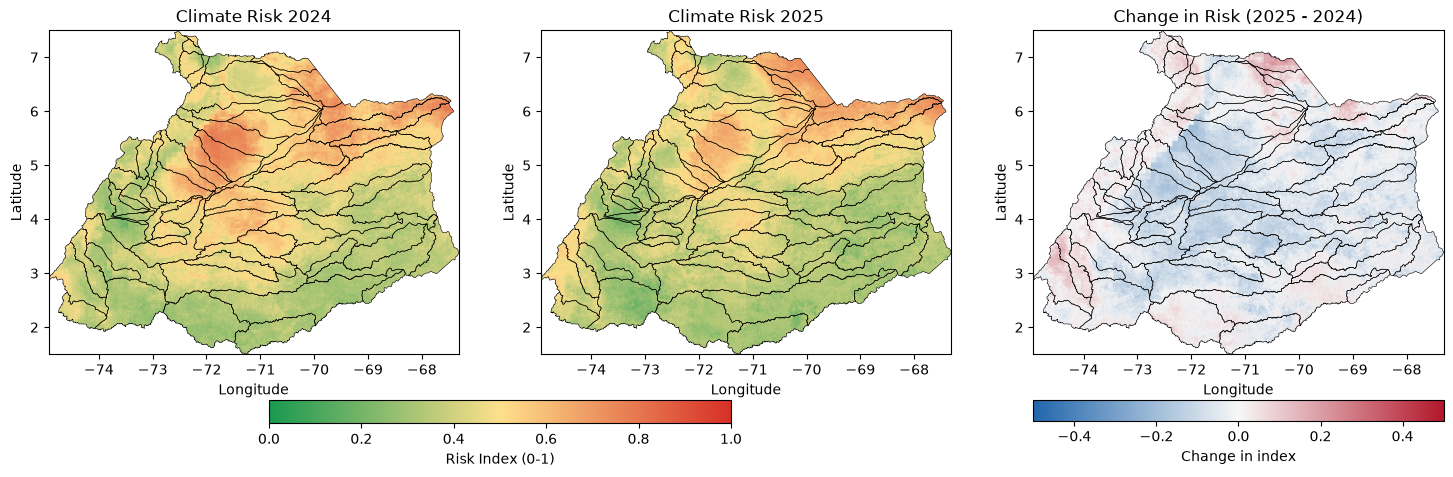

Preview generated from local file -- no Earth Engine call was made to draw this.


In [17]:
import geopandas as gpd

subbasins_geojson_path = os.path.join(OUTPUT_DIRS['aoi'], 'subbasins.geojson')
if not os.path.exists(subbasins_geojson_path):
    geemap.ee_export_vector(subbasins, filename=subbasins_geojson_path)
gdf_subbasins = gpd.read_file(subbasins_geojson_path)

cmap_risk = mcolors.LinearSegmentedColormap.from_list('risk', ['#1a9850', '#fee08b', '#d73027'])
cmap_change = mcolors.LinearSegmentedColormap.from_list('change', ['#2166ac', '#f7f7f7', '#b2182b'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
risk_arrays = {}
extent = None
for ax, year in zip(axes[:2], [REF_YEAR, EVAL_YEAR]):
    with rasterio.open(risk_tif_paths[year]) as src:
        arr = src.read(1, masked=True)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    risk_arrays[year] = arr
    im = ax.imshow(arr, cmap=cmap_risk, vmin=0, vmax=1, extent=extent)
    gdf_subbasins.boundary.plot(ax=ax, color='black', linewidth=0.4)
    ax.set_title(f'Climate Risk {year}')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

risk_change_arr = risk_arrays[EVAL_YEAR] - risk_arrays[REF_YEAR]
im2 = axes[2].imshow(risk_change_arr, cmap=cmap_change, vmin=-0.5, vmax=0.5, extent=extent)
gdf_subbasins.boundary.plot(ax=axes[2], color='black', linewidth=0.4)
axes[2].set_title(f'Change in Risk ({EVAL_YEAR} - {REF_YEAR})')
axes[2].set_xlabel('Longitude'); axes[2].set_ylabel('Latitude')

fig.colorbar(im, ax=axes[:2], orientation='horizontal', fraction=0.05, pad=0.1, label='Risk Index (0-1)')
fig.colorbar(im2, ax=axes[2], orientation='horizontal', fraction=0.05, pad=0.1, label='Change in index')
plt.show()

print('Preview generated from local file -- no Earth Engine call was made to draw this.')

### 12.0 Subbasin Columns (Compatible with Any Source)

In [18]:
def _detect_subbasin_columns(gdf):
    if 'HYBAS_ID' in gdf.columns:
        return 'HYBAS_ID', 'HYBAS_ID'
    if 'OBJECTID_1' in gdf.columns:
        label = 'NOM_SZH' if 'NOM_SZH' in gdf.columns else 'OBJECTID_1'
        return 'OBJECTID_1', label
    for candidate in gdf.columns:
        if candidate != 'geometry' and gdf[candidate].is_unique:
            return candidate, candidate
    gdf['_SUBBASIN_ID'] = range(len(gdf))
    return '_SUBBASIN_ID', '_SUBBASIN_ID'


SUBBASIN_ID_COL, SUBBASIN_LABEL_COL = _detect_subbasin_columns(gdf_subbasins)
SUBBASIN_KEY_COLS = [SUBBASIN_ID_COL] if SUBBASIN_LABEL_COL == SUBBASIN_ID_COL else [SUBBASIN_ID_COL, SUBBASIN_LABEL_COL]
print(f'Subbasin columns detected: id = "{SUBBASIN_ID_COL}", chart label = "{SUBBASIN_LABEL_COL}"')

Subbasin columns detected: id = "OBJECTID_1", chart label = "NOM_SZH"


## 11. Classification into Risk Categories

In [19]:
CLASS_LABELS = ['Very low', 'Low', 'Medium', 'High', 'Very high']

with rasterio.open(risk_tif_paths[REF_YEAR]) as src:
    ref_arr = src.read(1, masked=True)

p20, p40, p60, p80 = np.nanpercentile(ref_arr.filled(np.nan).astype('float64'), [20, 40, 60, 80])
print('Classification thresholds (reference-year quintiles, calculated locally with numpy):',
      p20, p40, p60, p80)

def classify_risk(img, p20, p40, p60, p80):
    return ee.Image(1) \
        .where(img.gt(p20), 2) \
        .where(img.gt(p40), 3) \
        .where(img.gt(p60), 4) \
        .where(img.gt(p80), 5) \
        .rename('Risk_Class')

risk_class_by_year = {
    year: classify_risk(img, float(p20), float(p40), float(p60), float(p80))
    for year, img in risk_by_year.items()
}
print('Classification complete (1=Very low ... 5=Very high).')

Classification thresholds (reference-year quintiles, calculated locally with numpy): 0.34349691271781924 0.40688176155090333 0.47186478972435 0.5576957941055298
Classification complete (1=Very low ... 5=Very high).


In [20]:
class _LocalThreshold:
    def __init__(self, value):
        self._value = float(value)

    def getInfo(self):
        return self._value

    def __float__(self):
        return self._value

    def __repr__(self):
        return f'<local threshold {self._value:.4f}>'


p20, p40, p60, p80 = (_LocalThreshold(x) for x in (p20, p40, p60, p80))
print('PATCH v43: p20..p80 wrapped with .getInfo() (Section 12.1 will work).')

PATCH v43: p20..p80 wrapped with .getInfo() (Section 12.1 will work).


## 12. Zonal Statistics by Subbasin (Optimized)

In [21]:
class_tif_paths = {}
for year in [REF_YEAR, EVAL_YEAR]:
    class_tif_paths[year] = export_ee_image_robust(
        risk_class_by_year[year],
        os.path.join(OUTPUT_DIRS['risk_class'], f'risk_class_{year}.tif'),
        region=aoi, scale=ANALYSIS_SCALE,
    )


print('Classification exported locally:')
for year, path in class_tif_paths.items():
    print(f'  {year}: {path}')

  outputs/06_risk_classification\risk_class_2024.tif already exists, reusing it.
  outputs/06_risk_classification\risk_class_2025.tif already exists, reusing it.
Classification exported locally:
  2024: outputs/06_risk_classification\risk_class_2024.tif
  2025: outputs/06_risk_classification\risk_class_2025.tif


In [22]:
import rioxarray
import geopandas as gpd

gdf_subbasins = gpd.read_file(subbasins_geojson_path)

risk_da = {}
class_da = {}

for year in [REF_YEAR, EVAL_YEAR]:
    risk_da[year] = rioxarray.open_rasterio(risk_tif_paths[year], masked=True).squeeze('band', drop=True)
    class_da[year] = rioxarray.open_rasterio(class_tif_paths[year], masked=True).squeeze('band', drop=True)

print('DataArrays ready:', {y: risk_da[y].shape for y in risk_da})

DataArrays ready: {2024: (2670, 3394), 2025: (2670, 3394)}


In [23]:
def mean_zonal_stats(gdf, data_array):
    result = zonal_stats(
        gdf, data_array.values, affine=data_array.rio.transform(),
        stats=['mean'], nodata=data_array.rio.nodata
    )
    return [r['mean'] for r in result]

def class_pct_zonal_stats(gdf, data_array):
    result = zonal_stats(
        gdf, data_array.values, affine=data_array.rio.transform(),
        categorical=True, nodata=data_array.rio.nodata
    )
    rows = []
    for r in result:
        total = sum(r.values()) or 1
        rows.append({f'pct_class_{int(k)}': v / total * 100 for k, v in r.items()})
    return pd.DataFrame(rows).reindex(columns=[f'pct_class_{i}' for i in range(1, 6)], fill_value=0.0)

df_zonal = gdf_subbasins[SUBBASIN_KEY_COLS].copy()
df_zonal['risk_mean_ref'] = mean_zonal_stats(gdf_subbasins, risk_da[REF_YEAR])
df_zonal['risk_mean_eval'] = mean_zonal_stats(gdf_subbasins, risk_da[EVAL_YEAR])
df_zonal['risk_change'] = df_zonal['risk_mean_eval'] - df_zonal['risk_mean_ref']


class_pct_eval = class_pct_zonal_stats(gdf_subbasins, class_da[EVAL_YEAR])
df_zonal = pd.concat([df_zonal.reset_index(drop=True), class_pct_eval.add_suffix(f'_{EVAL_YEAR}')], axis=1)

df_zonal = df_zonal.sort_values('risk_change', ascending=False)
zonal_csv_path = os.path.join(OUTPUT_DIRS['zonal_stats'], 'zonal_stats_subbasins.csv')
df_zonal.to_csv(zonal_csv_path, index=False)
print(f'Zonal statistics calculated for {len(df_zonal)} subbasins (local, rasterstats). '
      f'Saved to {zonal_csv_path}')
df_zonal.head(15)

Zonal statistics calculated for 73 subbasins (local, rasterstats). Saved to outputs/07_zonal_statistics\zonal_stats_subbasins.csv


,OBJECTID_1,NOM_SZH,risk_mean_ref,risk_mean_eval,risk_change,pct_class_1_2025,pct_class_2_2025,pct_class_3_2025,pct_class_4_2025,pct_class_5_2025
10,107,Directos Río Arauca (md),0.532015,0.663589,0.131574,NaN,0.154226,2.049310,2.188748,95.607716
66,291,Caño Samuco,0.570641,0.637998,0.067358,NaN,NaN,0.006737,3.240585,96.752678
49,151,Río Guape,0.389585,0.452690,0.063105,1.216443,16.807563,47.491288,33.860351,0.624355
2,40,Río Cobugón - Río Cobaría,0.444863,0.497454,0.052591,1.278493,7.511927,17.646325,68.779819,4.783436
6,74,Río Guayabero,0.401333,0.452041,0.050709,4.650749,22.353057,30.057838,41.422710,1.515646
1,38,Río Margua,0.432231,0.478381,0.046150,0.545274,6.824190,28.973893,63.656642,NaN
5,62,Río Bojabá,0.445717,0.488091,0.042374,4.958317,12.401242,14.095788,60.219038,8.325614
3,41,Alto Río Apure,0.480178,0.514817,0.034639,NaN,0.442684,5.661696,90.680336,3.215284
45,147,Río Guayuriba,0.334925,0.356007,0.021082,50.976521,24.084935,17.081857,7.856687,NaN
13,111,Río Cinaruco y Directos Río Orinoco,0.641915,0.662906,0.020991,NaN,0.035273,0.507387,2.104164,97.353177


### 12.1 Cross-Validation of the Classification Threshold

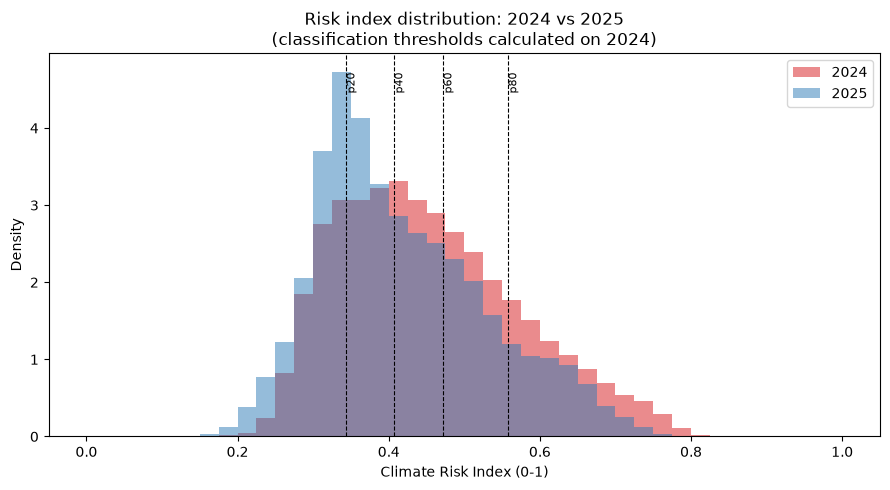

Histogram saved to outputs/06_risk_classification\risk_distribution_2024_2025.png


In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 41)
for year, color in zip([REF_YEAR, EVAL_YEAR], ['#d7191c', '#2c7bb6']):
    vals = risk_da[year].values.flatten()
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=bins, alpha=0.5, label=f'{year}', color=color, density=True)

thresholds = {'p20': p20.getInfo(), 'p40': p40.getInfo(), 'p60': p60.getInfo(), 'p80': p80.getInfo()}
ylim_top = ax.get_ylim()[1]
for label, val in thresholds.items():
    ax.axvline(val, color='black', linestyle='--', linewidth=0.8)
    ax.text(val, ylim_top * 0.95, label, rotation=90, va='top', fontsize=8)

ax.set_xlabel('Climate Risk Index (0-1)')
ax.set_ylabel('Density')
ax.set_title(f'Risk index distribution: {REF_YEAR} vs {EVAL_YEAR}\n(classification thresholds calculated on {REF_YEAR})')
ax.legend()
plt.tight_layout()

hist_fig_path = os.path.join(OUTPUT_DIRS['risk_class'], f'risk_distribution_{REF_YEAR}_{EVAL_YEAR}.png')
plt.savefig(hist_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Histogram saved to {hist_fig_path}')

## 13. Static Figures for the Poster

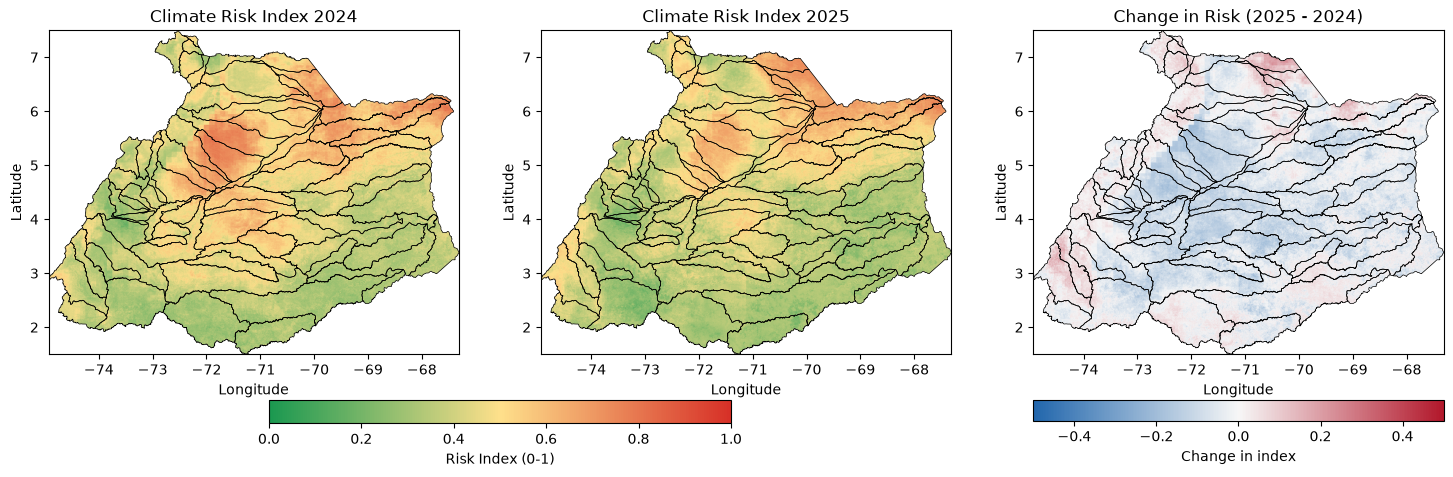

Figure saved to outputs/08_poster_figures\poster_figure_risk_2024_2025.png (300 dpi)


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = mcolors.LinearSegmentedColormap.from_list('risk', ['#1a9850', '#fee08b', '#d73027'])

for ax, year in zip(axes[:2], [REF_YEAR, EVAL_YEAR]):
    with rasterio.open(risk_tif_paths[year]) as src:
        arr = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=1, extent=extent)
    gdf_subbasins.boundary.plot(ax=ax, color='black', linewidth=0.5)
    ax.set_title(f'Climate Risk Index {year}', fontsize=12)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

with rasterio.open(risk_tif_paths[REF_YEAR]) as src_ref, \
     rasterio.open(risk_tif_paths[EVAL_YEAR]) as src_eval:
    arr_change = src_eval.read(1) - src_ref.read(1)
    extent = [src_ref.bounds.left, src_ref.bounds.right, src_ref.bounds.bottom, src_ref.bounds.top]

cmap_change = mcolors.LinearSegmentedColormap.from_list('change', ['#2166ac', '#f7f7f7', '#b2182b'])
im2 = axes[2].imshow(arr_change, cmap=cmap_change, vmin=-0.5, vmax=0.5, extent=extent)
gdf_subbasins.boundary.plot(ax=axes[2], color='black', linewidth=0.5)
axes[2].set_title(f'Change in Risk ({EVAL_YEAR} - {REF_YEAR})', fontsize=12)
axes[2].set_xlabel('Longitude'); axes[2].set_ylabel('Latitude')

fig.colorbar(im, ax=axes[:2], orientation='horizontal', fraction=0.05, pad=0.1, label='Risk Index (0-1)')
fig.colorbar(im2, ax=axes[2], orientation='horizontal', fraction=0.05, pad=0.1, label='Change in index')

poster_fig_path = os.path.join(OUTPUT_DIRS['poster_figures'], f'poster_figure_risk_{REF_YEAR}_{EVAL_YEAR}.png')
plt.savefig(poster_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure saved to {poster_fig_path} (300 dpi)')

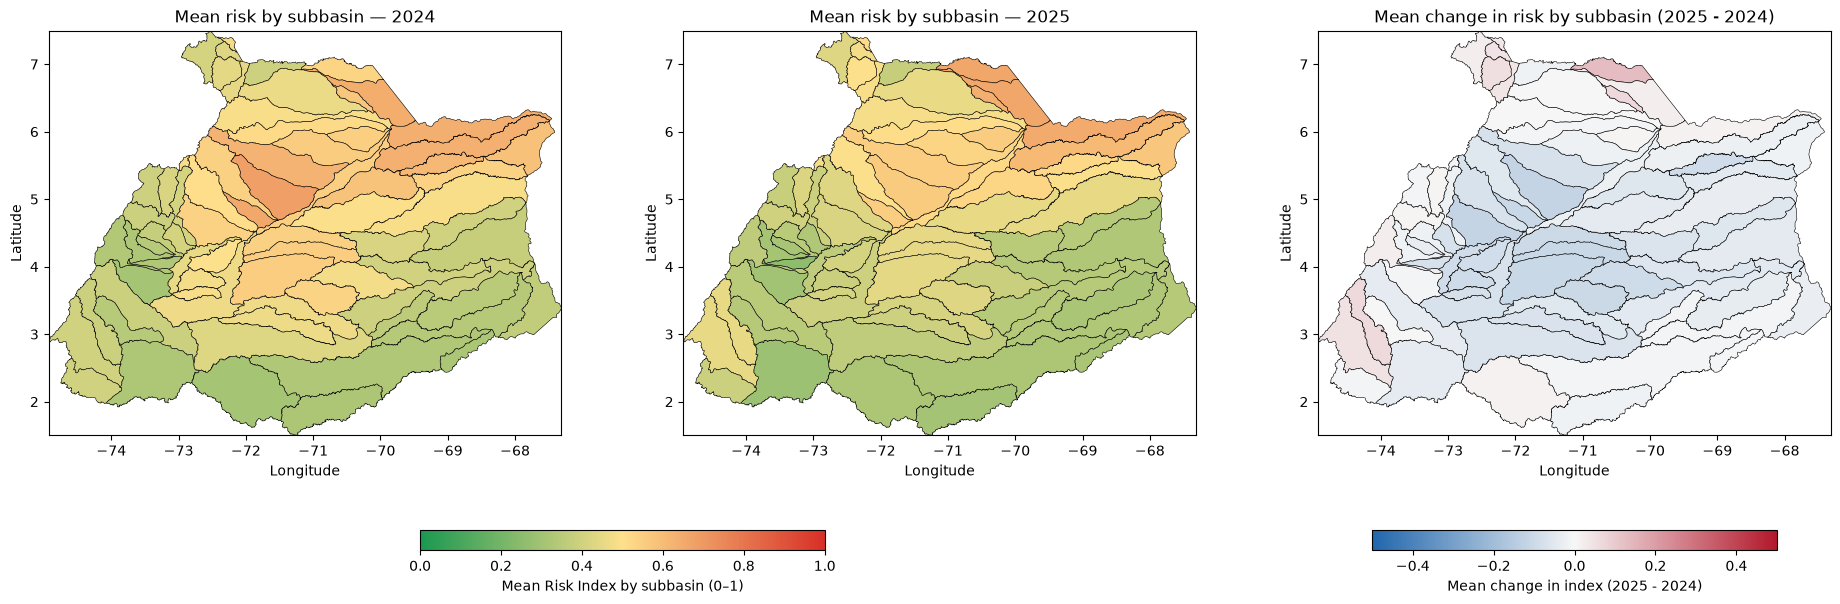

Figure by subbasin saved to outputs/08_poster_figures\poster_figure_risk_by_subbasin_2024_2025.png (300 dpi)


In [26]:
df_map = gdf_subbasins.merge(df_zonal, on=SUBBASIN_ID_COL, how='left')

cmap_risk_basin = mcolors.LinearSegmentedColormap.from_list(
    'risk_basin',
    ['#1a9850', '#fee08b', '#d73027']
)

cmap_change_basin = mcolors.LinearSegmentedColormap.from_list(
    'change_basin',
    ['#2166ac', '#f7f7f7', '#b2182b']
)


fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 6),
    constrained_layout=True
)


xmin, ymin, xmax, ymax = df_map.total_bounds


for ax, year, col in zip(
    axes[:2],
    [REF_YEAR, EVAL_YEAR],
    ['risk_mean_ref', 'risk_mean_eval']
):

    df_map.plot(
        column=col,
        cmap=cmap_risk_basin,
        linewidth=0.4,
        edgecolor='black',
        vmin=0,
        vmax=1,
        ax=ax
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(
        f'Mean risk by subbasin — {year}',
        fontsize=12
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')


df_map.plot(
    column='risk_change',
    cmap=cmap_change_basin,
    linewidth=0.4,
    edgecolor='black',
    vmin=-0.5,
    vmax=0.5,
    ax=axes[2]
)

axes[2].set_xlim(xmin, xmax)
axes[2].set_ylim(ymin, ymax)

axes[2].set_title(
    f'Mean change in risk by subbasin ({EVAL_YEAR} - {REF_YEAR})',
    fontsize=12
)

axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')


sm_risk = plt.cm.ScalarMappable(
    cmap=cmap_risk_basin,
    norm=plt.Normalize(vmin=0, vmax=1)
)
sm_risk.set_array([])

cbar1 = fig.colorbar(
    sm_risk,
    ax=axes[:2],
    orientation='horizontal',
    fraction=0.05,
    pad=0.12
)

cbar1.set_label(
    'Mean Risk Index by subbasin (0–1)',
    fontsize=10
)

sm_chg = plt.cm.ScalarMappable(
    cmap=cmap_change_basin,
    norm=plt.Normalize(vmin=-0.5, vmax=0.5)
)
sm_chg.set_array([])

cbar2 = fig.colorbar(
    sm_chg,
    ax=axes[2],
    orientation='horizontal',
    fraction=0.05,
    pad=0.12
)

cbar2.set_label(
    f'Mean change in index ({EVAL_YEAR} - {REF_YEAR})',
    fontsize=10
)

basin_fig_path = os.path.join(
    OUTPUT_DIRS['poster_figures'],
    f'poster_figure_risk_by_subbasin_{REF_YEAR}_{EVAL_YEAR}.png'
)

plt.savefig(
    basin_fig_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f'Figure by subbasin saved to {basin_fig_path} (300 dpi)'
)

### 13.1 Static Maps by Component (Hazard, Exposure, Vulnerability)

  outputs/04_components_hazard_exposure_vulnerability\Hazard_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Exposure_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Vulnerability_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Sensitivity_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\AdaptiveCapacity_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Hazard_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Exposure_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Vulnerability_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Sensitivity_Index_2025.tif already exists, reusing it.
  outputs/04_components_ha

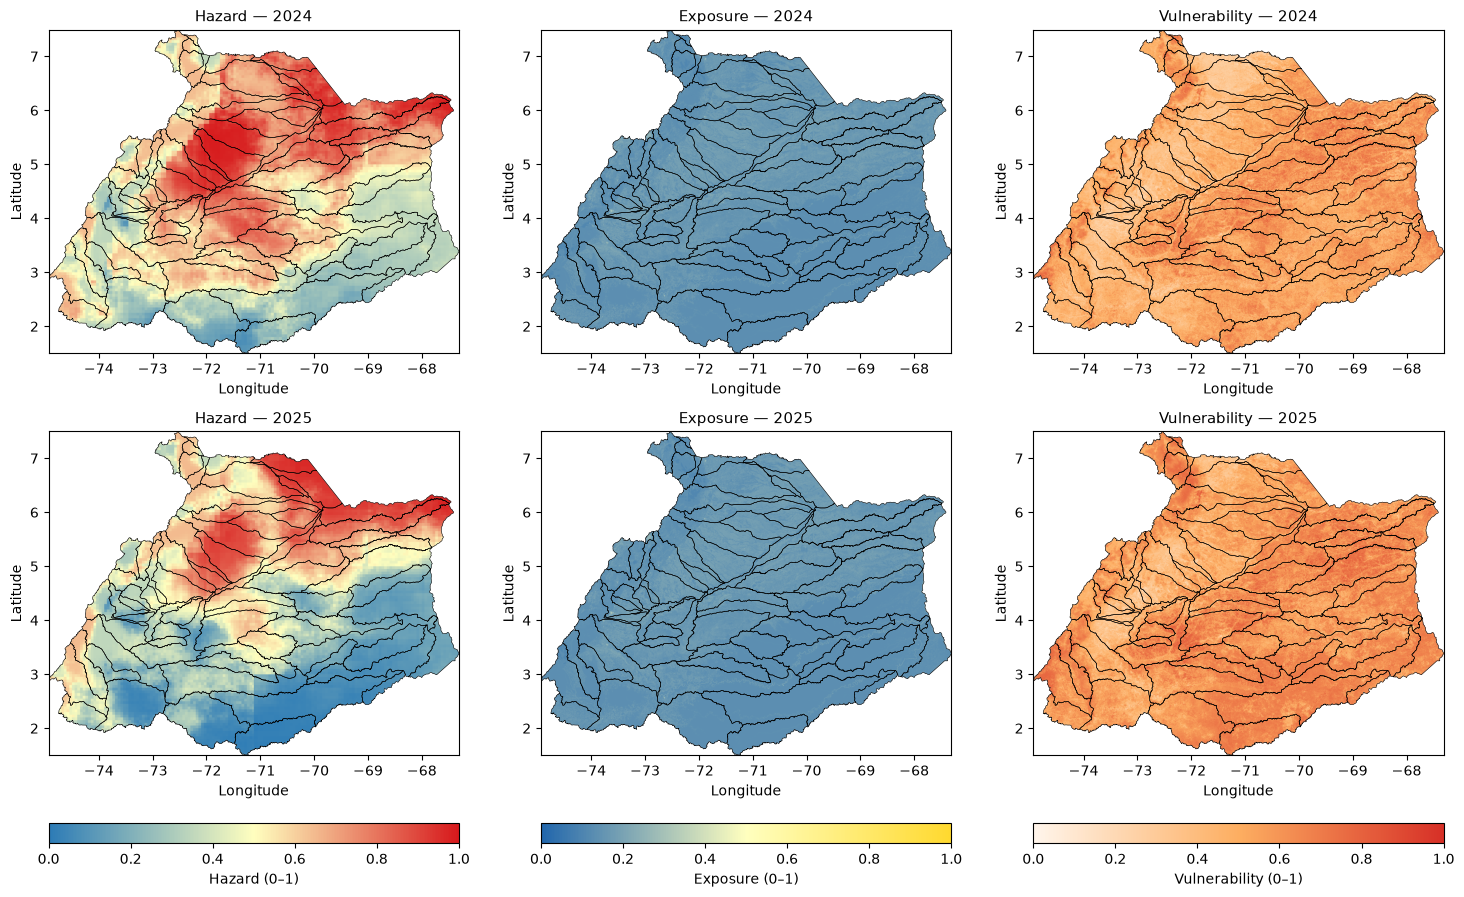

Component figure saved to outputs/08_poster_figures\component_maps_2024_2025.png (300 dpi)


In [27]:
component_tif_paths = {year: {} for year in [REF_YEAR, EVAL_YEAR]}

for year, comps in components_by_year.items():

    for name, img in comps.items():

        component_tif_paths[year][name] = export_ee_image_robust(
            img,
            os.path.join(OUTPUT_DIRS['components'], f'{name}_{year}.tif'),
            region=aoi,
            scale=ANALYSIS_SCALE,
        )

component_order = [
    'Hazard_Index',
    'Exposure_Index',
    'Vulnerability_Index'
]

component_labels = {
    'Hazard_Index': 'Hazard',
    'Exposure_Index': 'Exposure',
    'Vulnerability_Index': 'Vulnerability'
}


component_cmaps = {

    'Hazard_Index': mcolors.LinearSegmentedColormap.from_list(
        'hazard',
        ['#2c7bb6', '#ffffbf', '#d7191c']
    ),

    'Exposure_Index': mcolors.LinearSegmentedColormap.from_list(
        'exposure',
         ['#2166ac', '#ffffbf', '#ffd92f']
    ),

    'Vulnerability_Index': mcolors.LinearSegmentedColormap.from_list(
        'vulnerability',
        ['#fff5eb', '#fdae61', '#d73027']
    )
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row, year in enumerate([REF_YEAR, EVAL_YEAR]):

    for col, comp_name in enumerate(component_order):

        ax = axes[row, col]

        with rasterio.open(component_tif_paths[year][comp_name]) as src:

            arr = src.read(1)

            extent = [
                src.bounds.left,
                src.bounds.right,
                src.bounds.bottom,
                src.bounds.top
            ]

        im = ax.imshow(
            arr,
            cmap=component_cmaps[comp_name],
            vmin=0,
            vmax=1,
            extent=extent
        )

        gdf_subbasins.boundary.plot(
            ax=ax,
            color='black',
            linewidth=0.4
        )

        ax.set_title(
            f'{component_labels[comp_name]} — {year}',
            fontsize=11
        )

        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

for col, comp_name in enumerate(component_order):

    sm = plt.cm.ScalarMappable(
        cmap=component_cmaps[comp_name],
        norm=plt.Normalize(vmin=0, vmax=1)
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:, col],
        orientation='horizontal',
        fraction=0.05,
        pad=0.08
    )

    cbar.set_label(
        f'{component_labels[comp_name]} (0–1)',
        fontsize=10
    )

component_fig_path = os.path.join(
    OUTPUT_DIRS['poster_figures'],
    f'component_maps_{REF_YEAR}_{EVAL_YEAR}.png'
)

plt.savefig(
    component_fig_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f'Component figure saved to {component_fig_path} (300 dpi)'
)

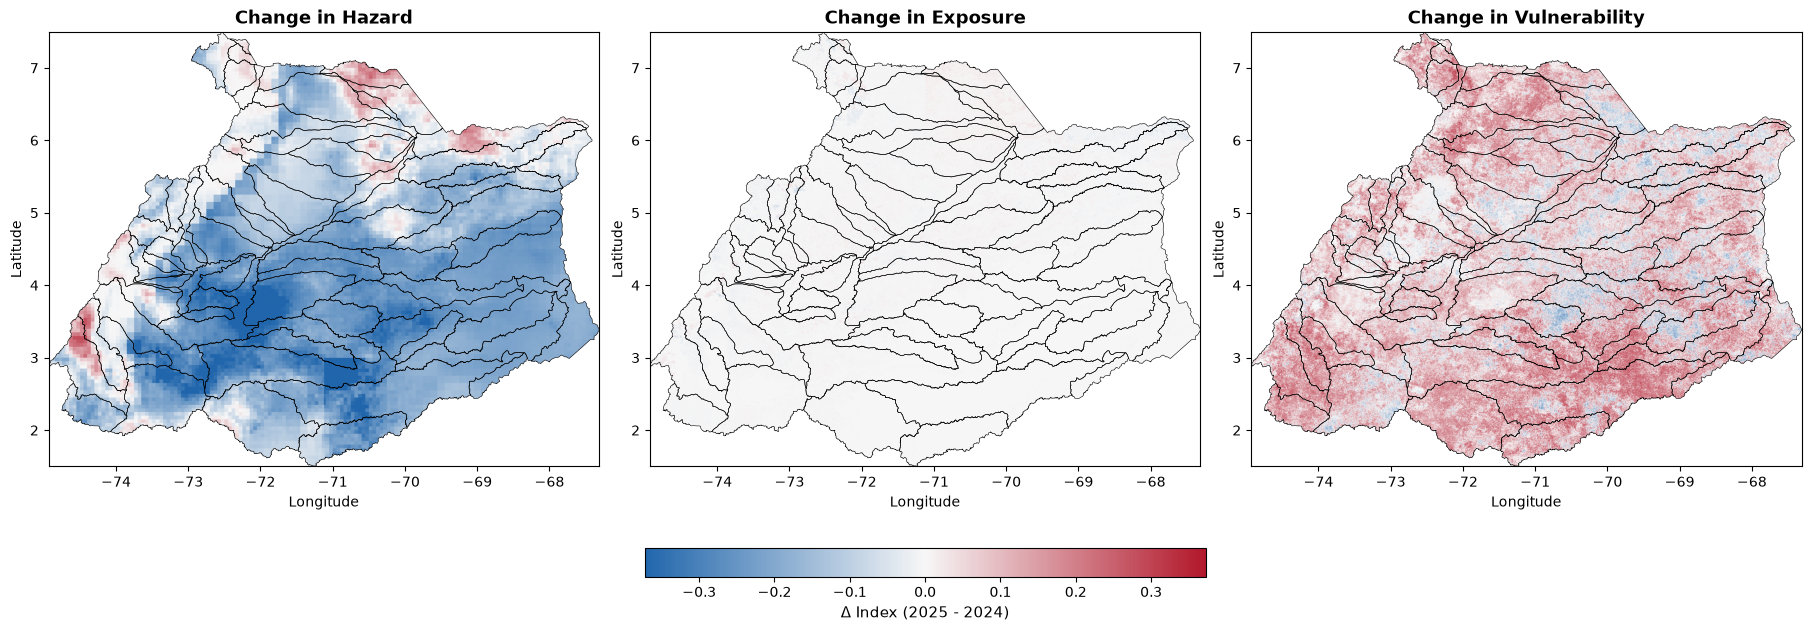

Figure saved to: outputs/08_poster_figures\component_changes_2024_2025.png


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio


component_order = [
    'Hazard_Index',
    'Exposure_Index',
    'Vulnerability_Index'
]

component_labels = {
    'Hazard_Index': 'Change in Hazard',
    'Exposure_Index': 'Change in Exposure',
    'Vulnerability_Index': 'Change in Vulnerability'
}


diff_arrays = {}
extent = None

for comp_name in component_order:

    with rasterio.open(component_tif_paths[REF_YEAR][comp_name]) as src_ref:
        arr_ref = src_ref.read(1).astype(float)

    with rasterio.open(component_tif_paths[EVAL_YEAR][comp_name]) as src_eval:
        arr_eval = src_eval.read(1).astype(float)

        extent = [
            src_eval.bounds.left,
            src_eval.bounds.right,
            src_eval.bounds.bottom,
            src_eval.bounds.top
        ]

    diff = arr_eval - arr_ref


    diff = np.where(
        np.isfinite(arr_ref) & np.isfinite(arr_eval),
        diff,
        np.nan
    )

    diff_arrays[comp_name] = diff


all_vals = np.concatenate([
    diff_arrays[c][np.isfinite(diff_arrays[c])].ravel()
    for c in component_order
])

vmax = np.nanpercentile(np.abs(all_vals), 99)
vmin = -vmax

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 11),
    constrained_layout=True
)

for ax, comp_name in zip(axes, component_order):

    im = ax.imshow(
        diff_arrays[comp_name],
        cmap=cmap_change,
        norm=norm,
        extent=extent
    )

    gdf_subbasins.boundary.plot(
        ax=ax,
        color='black',
        linewidth=0.4
    )

    ax.set_title(
        component_labels[comp_name],
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')


cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    shrink=0.75,
    pad=0.04,
    fraction=0.03
)

cbar.set_label(
    f'Δ Index ({EVAL_YEAR} - {REF_YEAR})',
    fontsize=11
)


diff_fig_path = os.path.join(
    OUTPUT_DIRS['poster_figures'],
    f'component_changes_{REF_YEAR}_{EVAL_YEAR}.png'
)

plt.savefig(
    diff_fig_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Figure saved to: {diff_fig_path}')

### 13.1b Sensitivity vs. Adaptive Capacity (within Vulnerability)

  outputs/04_components_hazard_exposure_vulnerability\Sensitivity_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\AdaptiveCapacity_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Sensitivity_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\AdaptiveCapacity_Index_2025.tif already exists, reusing it.


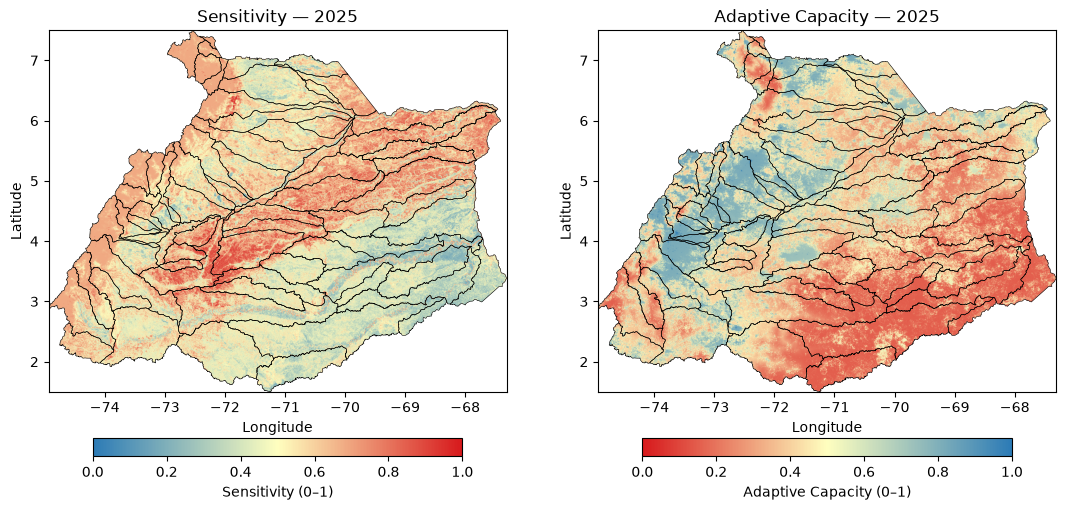

Sensitivity vs. Adaptive Capacity figure saved to outputs/08_poster_figures\sensitivity_vs_adaptive_capacity_2025.png (300 dpi)
Note: the Adaptive Capacity map is shown in its "direct" direction (higher value = higher capacity); in Section 9 it is inverted before being combined into Vulnerability.


In [29]:
cmap_comp = mcolors.LinearSegmentedColormap.from_list(
    'comp',
    ['#2c7bb6', '#ffffbf', '#d7191c']
)


cmap_comp_r = mcolors.LinearSegmentedColormap.from_list(
    'comp_r',
    ['#d7191c', '#ffffbf', '#2c7bb6']
)

subindex_tif_paths = {year: {} for year in [REF_YEAR, EVAL_YEAR]}

for year in [REF_YEAR, EVAL_YEAR]:

    for name in ['Sensitivity_Index', 'AdaptiveCapacity_Index']:

        subindex_tif_paths[year][name] = export_ee_image_robust(
            components_by_year[year][name],
            os.path.join(OUTPUT_DIRS['components'], f'{name}_{year}.tif'),
            region=aoi,
            scale=ANALYSIS_SCALE,
        )

subindex_labels = {
    'Sensitivity_Index': 'Sensitivity',
    'AdaptiveCapacity_Index': 'Adaptive Capacity'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, name in zip(axes, ['Sensitivity_Index', 'AdaptiveCapacity_Index']):

    with rasterio.open(subindex_tif_paths[EVAL_YEAR][name]) as src:

        arr = src.read(1)

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]


    cmap = cmap_comp if name == 'Sensitivity_Index' else cmap_comp_r

    im = ax.imshow(
        arr,
        cmap=cmap,
        vmin=0,
        vmax=1,
        extent=extent
    )

    gdf_subbasins.boundary.plot(
        ax=ax,
        color='black',
        linewidth=0.4
    )

    ax.set_title(
        f'{subindex_labels[name]} — {EVAL_YEAR}',
        fontsize=12
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')


fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(0, 1),
        cmap=cmap_comp
    ),
    ax=axes[0],
    orientation='horizontal',
    fraction=0.04,
    pad=0.10,
    label='Sensitivity (0–1)'
)


fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(0, 1),
        cmap=cmap_comp_r
    ),
    ax=axes[1],
    orientation='horizontal',
    fraction=0.04,
    pad=0.10,
    label='Adaptive Capacity (0–1)'
)

subindex_fig_path = os.path.join(
    OUTPUT_DIRS['poster_figures'],
    f'sensitivity_vs_adaptive_capacity_{EVAL_YEAR}.png'
)

plt.savefig(
    subindex_fig_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f'Sensitivity vs. Adaptive Capacity figure saved to '
    f'{subindex_fig_path} (300 dpi)'
)

print(
    'Note: the Adaptive Capacity map is shown in its "direct" '
    'direction (higher value = higher capacity); in Section 9 it is '
    'inverted before being combined into Vulnerability.'
)

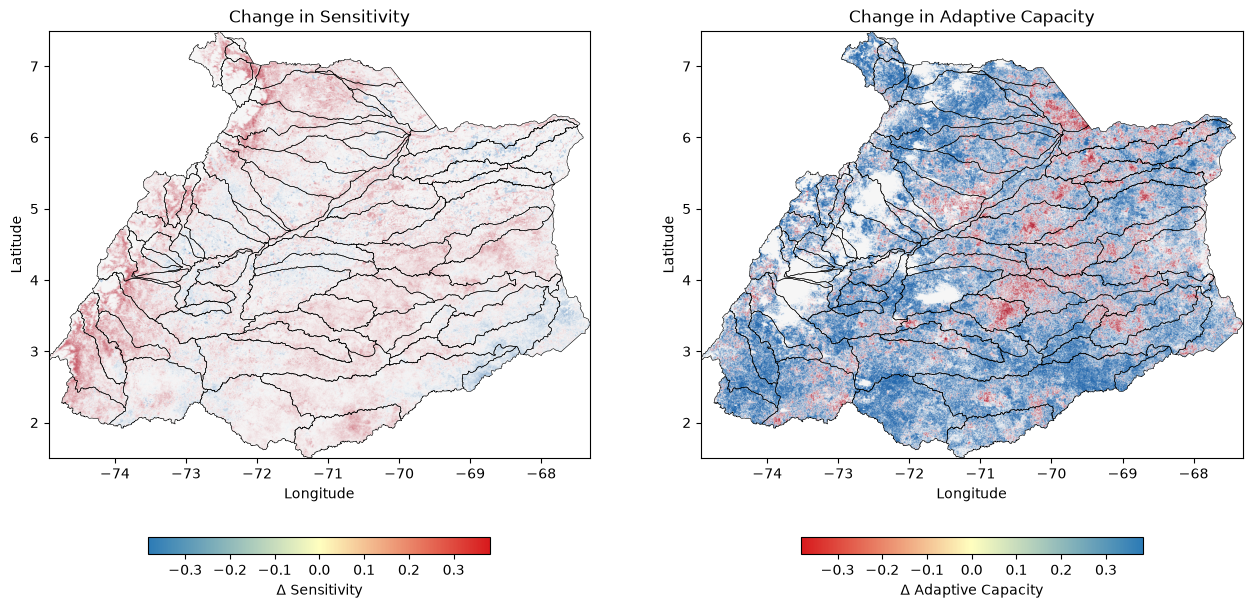

In [30]:
subindex_order = [
    'Sensitivity_Index',
    'AdaptiveCapacity_Index'
]

subindex_labels = {
    'Sensitivity_Index': 'Change in Sensitivity',
    'AdaptiveCapacity_Index': 'Change in Adaptive Capacity'
}


cmap_sensitivity_change = mcolors.LinearSegmentedColormap.from_list(
    'sens_change',
    ['#2c7bb6', '#ffffbf', '#d7191c']
)

cmap_adaptive_change = mcolors.LinearSegmentedColormap.from_list(
    'adapt_change',
    ['#d7191c', '#ffffbf', '#2c7bb6']
)


diff_arrays = {}
extent = None

for name in subindex_order:

    with rasterio.open(subindex_tif_paths[REF_YEAR][name]) as src:
        arr_ref = src.read(1).astype(float)

    with rasterio.open(subindex_tif_paths[EVAL_YEAR][name]) as src:
        arr_eval = src.read(1).astype(float)

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

    diff = arr_eval - arr_ref

    diff = np.where(
        np.isfinite(arr_ref) & np.isfinite(arr_eval),
        diff,
        np.nan
    )

    diff_arrays[name] = diff


all_vals = np.concatenate([
    diff_arrays[k][np.isfinite(diff_arrays[k])].ravel()
    for k in subindex_order
])

vmax = np.nanpercentile(np.abs(all_vals), 99)

norm = mcolors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)


fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 6),
    constrained_layout=True
)

cmaps = {
    'Sensitivity_Index': cmap_sensitivity_change,
    'AdaptiveCapacity_Index': cmap_adaptive_change
}

for ax, name in zip(axes, subindex_order):

    im = ax.imshow(
        diff_arrays[name],
        cmap=cmap_change,
        norm=norm,
        extent=extent
    )

    gdf_subbasins.boundary.plot(
        ax=ax,
        color='black',
        linewidth=0.4
    )

    ax.set_title(
        subindex_labels[name],
        fontsize=12
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')


for ax, name in zip(axes, subindex_order):

    sm = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmaps[name]
    )

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation='horizontal',
        fraction=0.04,
        pad=0.08
    )

    cbar.set_label(
        f'Δ {subindex_labels[name].replace("Change in ", "")}'
    )


subindex_change_fig_path = os.path.join(
    OUTPUT_DIRS['poster_figures'],
    f'sensitivity_adaptive_change_{REF_YEAR}_{EVAL_YEAR}.png'
)

plt.savefig(
    subindex_change_fig_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 13.2 Which Component Weighs Most in Each Subbasin?

In [31]:
component_da = {}
for year in [REF_YEAR, EVAL_YEAR]:
    component_da[year] = {
        name: rioxarray.open_rasterio(path, masked=True).squeeze('band', drop=True)
        for name, path in component_tif_paths[year].items()
    }

component_key_map = {'Hazard_Index': 'Hazard', 'Exposure_Index': 'Exposure', 'Vulnerability_Index': 'Vulnerability'}

df_components = gdf_subbasins[SUBBASIN_KEY_COLS].copy()
for comp_name in component_order:
    df_components[f'{comp_name}_{EVAL_YEAR}'] = mean_zonal_stats(gdf_subbasins, component_da[EVAL_YEAR][comp_name])
    w = weights_components[component_key_map[comp_name]]
    df_components[f'{comp_name}_weighted'] = df_components[f'{comp_name}_{EVAL_YEAR}'] * w

weighted_cols = [f'{c}_weighted' for c in component_order]
weighted_values = df_components[weighted_cols].values
weighted_sum = weighted_values.sum(axis=1)
dominant_idx = weighted_values.argmax(axis=1)

df_components['dominant_component'] = [component_labels[component_order[i]] for i in dominant_idx]
df_components['dominant_share_pct'] = (
    weighted_values[np.arange(len(weighted_values)), dominant_idx] / weighted_sum
) * 100

dominant_csv_path = os.path.join(OUTPUT_DIRS['zonal_stats'], 'dominant_component_by_subbasin.csv')
df_components.to_csv(dominant_csv_path, index=False)
print(f'Dominant component calculated for {len(df_components)} subbasins ({EVAL_YEAR}). '
      f'Saved to {dominant_csv_path}')
print(df_components['dominant_component'].value_counts())
df_components.head(15)

Dominant component calculated for 73 subbasins (2025). Saved to outputs/07_zonal_statistics\dominant_component_by_subbasin.csv
dominant_component
Change in Vulnerability    48
Change in Hazard           25
Name: count, dtype: int64


,OBJECTID_1,NOM_SZH,Hazard_Index_2025,Hazard_Index_weighted,Exposure_Index_2025,Exposure_Index_weighted,Vulnerability_Index_2025,Vulnerability_Index_weighted,dominant_component,dominant_share_pct
0,37,Río Chítaga,0.464595,0.157962,0.147595,0.048706,0.605528,0.199824,Change in Vulnerability,49.158089
1,38,Río Margua,0.586952,0.199564,0.137361,0.045329,0.622907,0.205559,Change in Vulnerability,45.633975
2,40,Río Cobugón - Río Cobaría,0.590559,0.200790,0.135454,0.044700,0.665231,0.219526,Change in Vulnerability,47.208317
3,41,Alto Río Apure,0.605069,0.205723,0.128144,0.042287,0.699484,0.230830,Change in Vulnerability,48.205993
4,42,Río Garagoa,0.405540,0.137884,0.159876,0.052759,0.534827,0.176493,Change in Vulnerability,48.072955
5,62,Río Bojabá,0.580825,0.197481,0.138979,0.045863,0.646263,0.213267,Change in Vulnerability,46.706477
6,74,Río Guayabero,0.505101,0.171734,0.140855,0.046482,0.627000,0.206910,Change in Vulnerability,48.670223
7,104,Rio Banadia y otros Directos al Río Arauca,0.487084,0.165609,0.162180,0.053519,0.430889,0.142193,Change in Hazard,45.834156
8,105,Caño Aguaclarita,0.755799,0.256972,0.173251,0.057173,0.597782,0.197268,Change in Hazard,50.247430
9,106,Directos Orinoco entre ríos Tomo y Meta (mi),0.746207,0.253711,0.166580,0.054971,0.624674,0.206142,Change in Hazard,49.281006


In [32]:
df_zonal.columns

Index(['OBJECTID_1', 'NOM_SZH', 'risk_mean_ref', 'risk_mean_eval',
       'risk_change', 'pct_class_1_2025', 'pct_class_2_2025',
       'pct_class_3_2025', 'pct_class_4_2025', 'pct_class_5_2025'],
      dtype='str')

In [33]:
df_plot = df_components.merge(
    df_zonal[[SUBBASIN_ID_COL, 'risk_mean_eval']],
    on=SUBBASIN_ID_COL
)


df_plot['total_risk_weighted'] = (
    df_plot['Hazard_Index_weighted'] +
    df_plot['Exposure_Index_weighted'] +
    df_plot['Vulnerability_Index_weighted']
)


df_plot = df_plot.sort_values(
    'total_risk_weighted',
    ascending=False
).reset_index(drop=True)

comp_colors = {
    'Hazard_Index': '#d7191c',
    'Exposure_Index': '#fdae61',
    'Vulnerability_Index': '#2c7bb6'
}

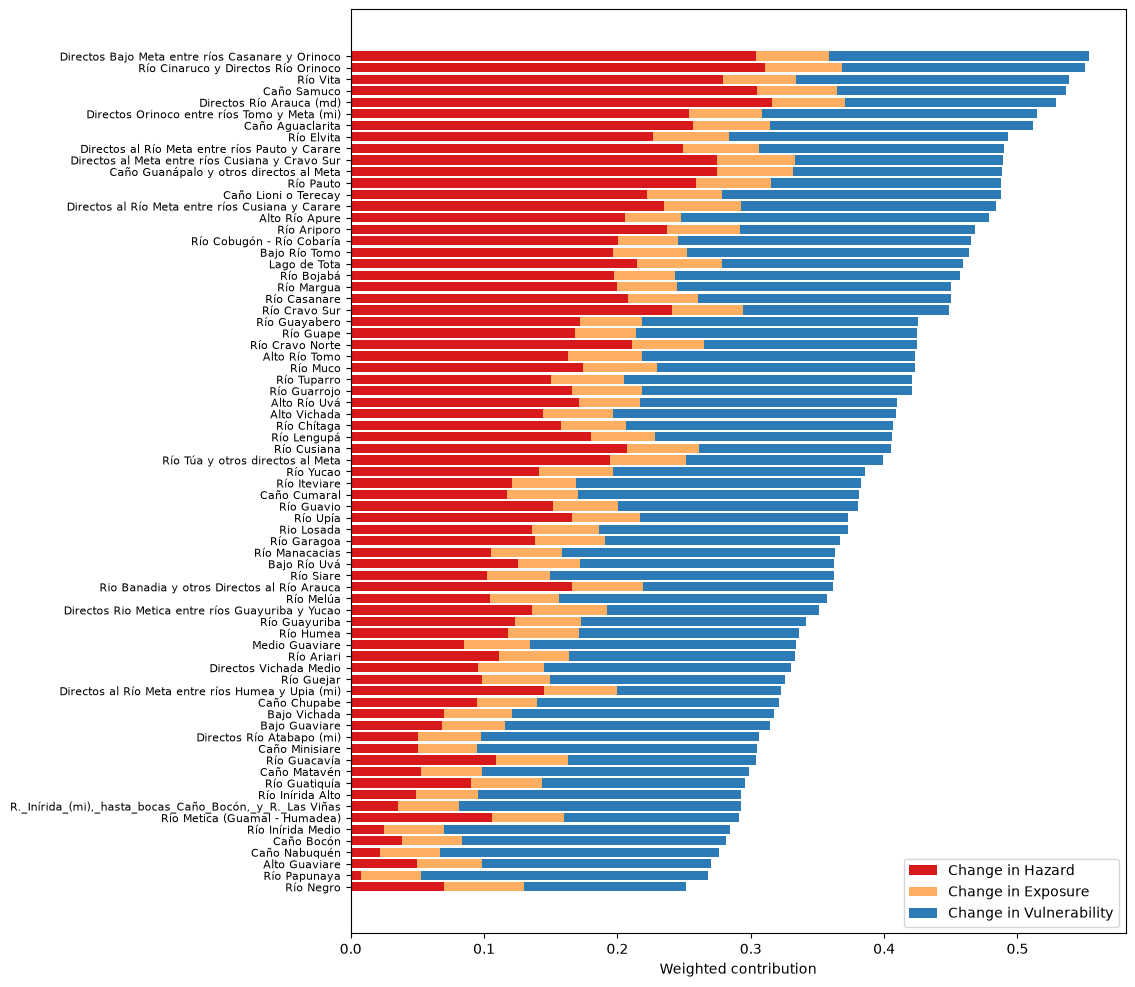

In [34]:
fig, ax = plt.subplots(figsize=(10, 12))

y = np.arange(len(df_plot))

left = np.zeros(len(df_plot))

for comp_name in component_order:
    vals = df_plot[f'{comp_name}_weighted']

    ax.barh(
        y,
        vals,
        left=left,
        color=comp_colors[comp_name],
        label=component_labels[comp_name]
    )

    left += vals

ax.set_yticks(y)
ax.set_yticklabels(df_plot[SUBBASIN_LABEL_COL], fontsize=8)

ax.invert_yaxis()
ax.set_xlabel("Weighted contribution")
ax.legend()

<Figure size 640x480 with 0 Axes>

Composition-by-subbasin figure saved to outputs/08_poster_figures\component_composition_by_subbasin.png


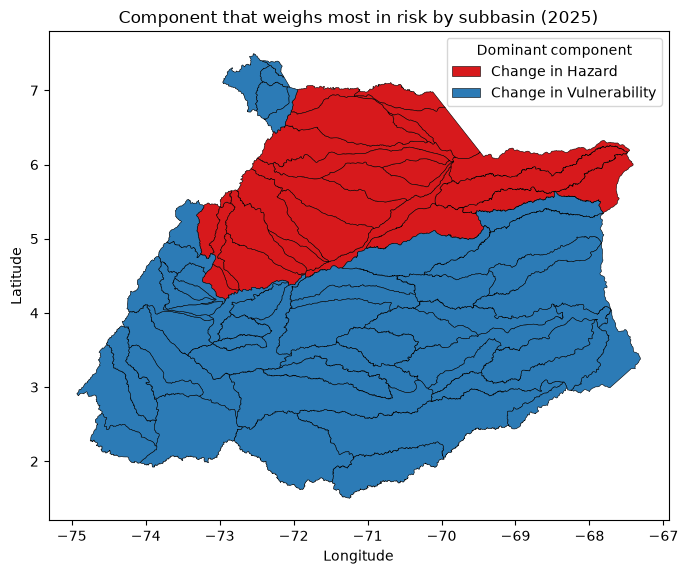

Dominant component map saved to outputs/08_poster_figures\dominant_component_map.png


In [35]:
composition_fig_path = os.path.join(OUTPUT_DIRS['poster_figures'], 'component_composition_by_subbasin.png')
plt.savefig(composition_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Composition-by-subbasin figure saved to {composition_fig_path}')


gdf_dominant = gdf_subbasins.merge(df_components[[SUBBASIN_ID_COL, 'dominant_component']], on=SUBBASIN_ID_COL)
dominant_colors = {'Change in Hazard': '#d7191c', 'Change in Exposure': '#fdae61', 'Change in Vulnerability': '#2c7bb6'}

fig, ax = plt.subplots(figsize=(8, 8))
for label, color in dominant_colors.items():
    subset = gdf_dominant[gdf_dominant['dominant_component'] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.4, label=label)
ax.legend(title='Dominant component')
ax.set_title(f'Component that weighs most in risk by subbasin ({EVAL_YEAR})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

dominant_map_path = os.path.join(OUTPUT_DIRS['poster_figures'], 'dominant_component_map.png')
plt.savefig(dominant_map_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Dominant component map saved to {dominant_map_path}')

## 14. Weight Sensitivity

In [36]:
N_RUNS = 30
PERTURBATION = 0.20
rng = np.random.default_rng(42)


fuzzy_arrays = {}
for name, img in fuzzy_by_year[EVAL_YEAR].items():
    path = export_ee_image_robust(
        img,
        os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_{name}_{EVAL_YEAR}.tif'),
        region=aoi, scale=ANALYSIS_SCALE,
    )
    with rasterio.open(path) as src:
        fuzzy_arrays[name] = src.read(1)

print('Fuzzy indicators exported as arrays:', list(fuzzy_arrays.keys()))

  outputs/03_fuzzification\fuzzy_H_precip_mean_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_H_precip_cv_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_H_temp_mean_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_E_cropland_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_E_wetland_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_E_water_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_E_built_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_E_grass_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_E_population_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_V_ndvi_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_V_slope_2025.tif already exists, reusing it.
  outputs/03_fuzzification\fuzzy_V_soil_organic_carbon_2025.tif already exists, reusing it.
  outputs/03_fuzzification\

In [37]:
def force_finite(arr, fill=0.0):
    a = np.asarray(arr, dtype='float32').copy()
    if np.isnan(a).any():
        a[np.isnan(a)] = fill
    return a


def diagnose_nan(layers, tag='layers'):
    per_layer = {k: int(np.isnan(v).sum()) for k, v in layers.items()}
    counts = sorted(set(per_layer.values()))
    print(f'--- NaN Diagnosis ({tag}) ---')
    for k, n in per_layer.items():
        print(f'  {k:24s} NaN = {n:9d}')
    if len(counts) == 1:
        print(f'  -> SINGLE (shared) mask: {counts[0]} px '
              f'({counts[0]/np.prod(next(iter(layers.values())).shape)*100:.2f}%)')
    else:
        print('  -> DIFFERENT masks per layer (not a single no-data zone)')
    return per_layer


n_before = diagnose_nan(fuzzy_arrays, tag='fuzzy arrays (evaluation)')


fuzzy_arrays = {k: force_finite(v) for k, v in fuzzy_arrays.items()}


n_after = {k: int(np.isnan(v).sum()) for k, v in fuzzy_arrays.items()}
assert max(n_after.values()) == 0, 'unfilled NaN remain'
print(f'OK: {len(n_after)} layers filled (NaN -> 0). '
      f'Recalculable baseline mean: {np.nanmean(list(fuzzy_arrays.values())):.4f}')

--- NaN Diagnosis (fuzzy arrays (evaluation)) ---
  H_precip_mean            NaN =   3473978
  H_precip_cv              NaN =   3473978
  H_temp_mean              NaN =   3473978
  E_cropland               NaN =   3473978
  E_wetland                NaN =   3473978
  E_water                  NaN =   3473978
  E_built                  NaN =   3473978
  E_grass                  NaN =   3473978
  E_population             NaN =   3473978
  V_ndvi                   NaN =   3473978
  V_slope                  NaN =   3473978
  V_soil_organic_carbon    NaN =   3473978
  V_burned_frequency       NaN =   3473978
  V_nightlights            NaN =   3473978
  V_accessibility          NaN =   3473978
  V_built_surface          NaN =   3473978
  -> SINGLE (shared) mask: 3473978 px (38.34%)
OK: 16 layers filled (NaN -> 0). Recalculable baseline mean: 0.2149


In [38]:
def perturb_weights(weights, rng, pct=PERTURBATION):
    perturbed = {k: v * (1 + rng.uniform(-pct, pct)) for k, v in weights.items()}
    total = sum(perturbed.values())
    return {k: v / total for k, v in perturbed.items()}


def _fuzzy_gamma_numpy(components, weights, gamma):
    fuzzy_and = None
    fuzzy_or_complement = None
    for name, arr in components.items():
        w = weights[name]
        term_and = np.power(arr, w)
        term_or = np.power(1 - arr, w)
        fuzzy_and = term_and if fuzzy_and is None else fuzzy_and * term_and
        fuzzy_or_complement = term_or if fuzzy_or_complement is None else fuzzy_or_complement * term_or
    fuzzy_or = 1 - fuzzy_or_complement
    return np.power(fuzzy_and, 1 - gamma) * np.power(fuzzy_or, gamma)


def compute_risk_numpy(fuzzy_arrays, w_h, w_e, w_sens, w_ac, w_vuln_sub, w_c, gamma):
    def wsum(weights):
        out = None
        for k, w in weights.items():
            term = fuzzy_arrays[k] * w
            out = term if out is None else out + term
        return out

    hazard = wsum(w_h)
    exposure = wsum(w_e)
    sensitivity = wsum(w_sens)
    adaptive_capacity = wsum(w_ac)

    vulnerability = _fuzzy_gamma_numpy(
        {'Sensitivity': sensitivity, 'AdaptiveCapacity': 1 - adaptive_capacity}, w_vuln_sub, gamma
    )
    risk = _fuzzy_gamma_numpy(
        {'Hazard': hazard, 'Exposure': exposure, 'Vulnerability': vulnerability}, w_c, gamma
    )
    return risk


baseline_risk = compute_risk_numpy(
    fuzzy_arrays, weights_hazard, weights_exposure, weights_sensitivity, weights_adaptive_capacity,
    weights_vulnerability_subcomponents, weights_components, GAMMA
)


def run_weight_sensitivity(perturb_component, n_runs, rng):
    runs = []
    for _ in range(n_runs):
        w_h = perturb_weights(weights_hazard, rng) if perturb_component in ('Hazard', 'All') else weights_hazard
        w_e = perturb_weights(weights_exposure, rng) if perturb_component in ('Exposure', 'All') else weights_exposure
        w_sens = perturb_weights(weights_sensitivity, rng) if perturb_component in ('Sensitivity', 'All') else weights_sensitivity
        w_ac = perturb_weights(weights_adaptive_capacity, rng) if perturb_component in ('AdaptiveCapacity', 'All') else weights_adaptive_capacity
        w_vuln_sub = perturb_weights(weights_vulnerability_subcomponents, rng) \
            if perturb_component in ('Sensitivity', 'AdaptiveCapacity', 'All') else weights_vulnerability_subcomponents
        w_c = perturb_weights(weights_components, rng) if perturb_component == 'All' else weights_components
        runs.append(compute_risk_numpy(fuzzy_arrays, w_h, w_e, w_sens, w_ac, w_vuln_sub, w_c, GAMMA))

    stack = np.stack(runs, axis=0)
    risk_std = stack.std(axis=0)

    flat_baseline = baseline_risk.flatten()
    correlations = []
    for run in runs:
        valid = ~np.isnan(flat_baseline) & ~np.isnan(run.flatten())
        rho, _ = spearmanr(flat_baseline[valid], run.flatten()[valid])
        correlations.append(rho)

    return risk_std, correlations, stack


print('Sensitivity functions defined. Baseline risk index calculated '
      f'(mean = {np.nanmean(baseline_risk):.3f}).')

Sensitivity functions defined. Baseline risk index calculated (mean = 0.258).


--- Sensitivity: Hazard ---
  Risk standard deviation (STUDY AREA): mean = 0.0052, max = 0.0170
  Spearman vs. baseline map (subbasins only): mean = 0.999, min = 0.995


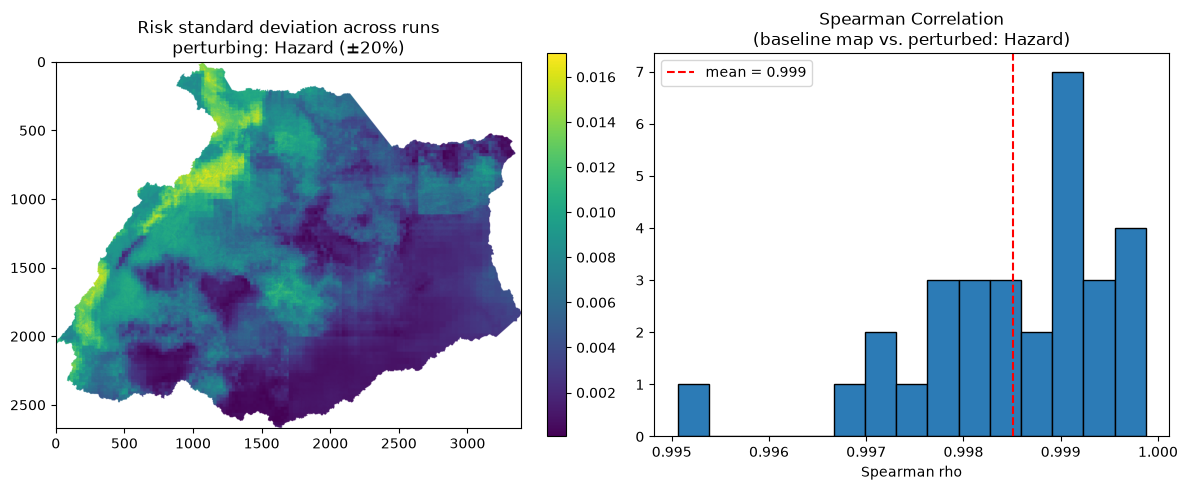

  Saved to outputs/09_weight_sensitivity\hazard/
--- Sensitivity: Exposure ---
  Risk standard deviation (STUDY AREA): mean = 0.0028, max = 0.0075
  Spearman vs. baseline map (subbasins only): mean = 1.000, min = 1.000


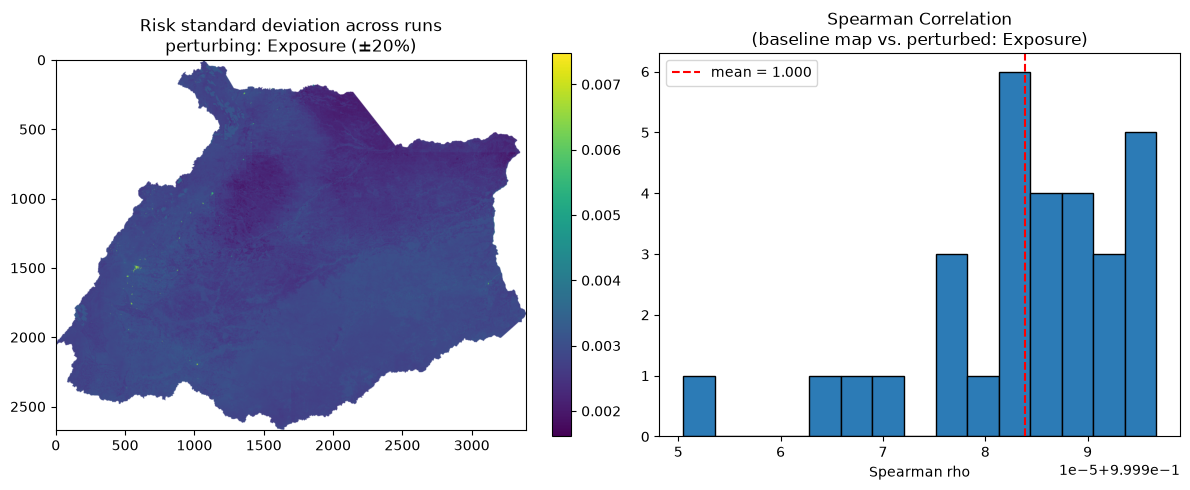

  Saved to outputs/09_weight_sensitivity\exposure/
--- Sensitivity: Sensitivity ---
  Risk standard deviation (STUDY AREA): mean = 0.0064, max = 0.0196
  Spearman vs. baseline map (subbasins only): mean = 0.997, min = 0.991


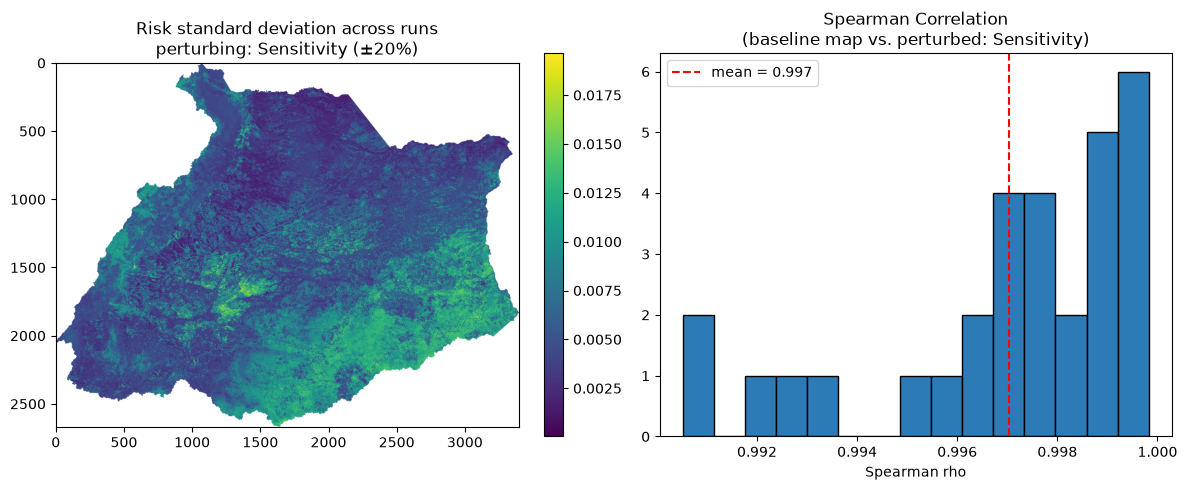

  Saved to outputs/09_weight_sensitivity\sensitivity/
--- Sensitivity: Adaptive Capacity ---
  Risk standard deviation (STUDY AREA): mean = 0.0054, max = 0.0168
  Spearman vs. baseline map (subbasins only): mean = 0.998, min = 0.993


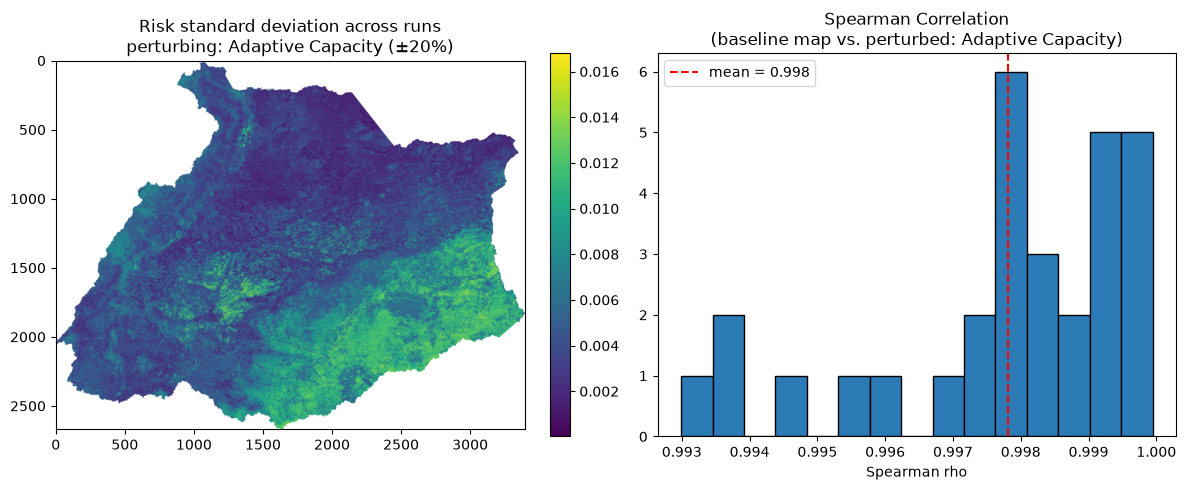

  Saved to outputs/09_weight_sensitivity\adaptivecapacity/
--- Sensitivity: All weights ---
  Risk standard deviation (STUDY AREA): mean = 0.0190, max = 0.0324
  Spearman vs. baseline map (subbasins only): mean = 0.992, min = 0.959


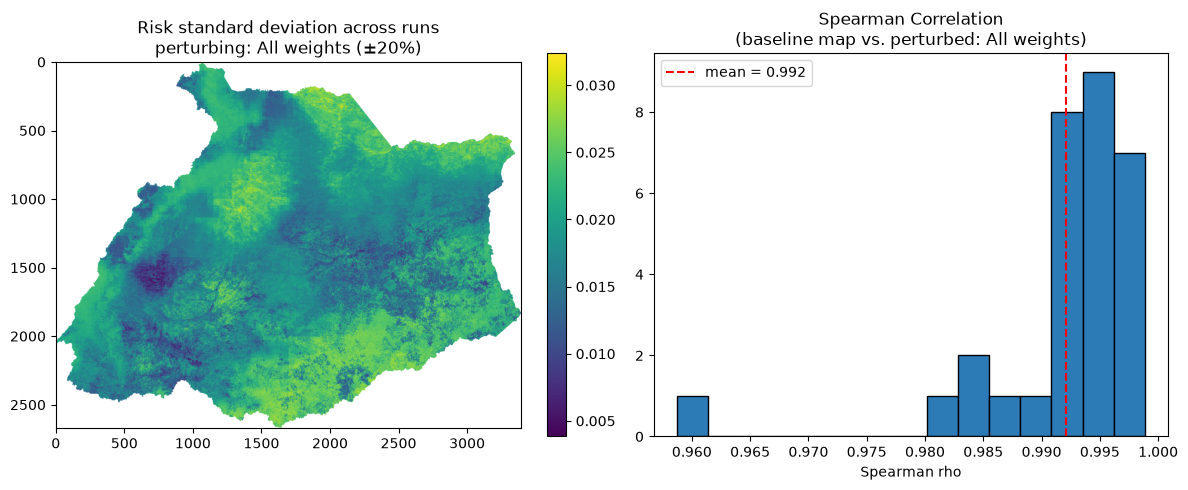

  Saved to outputs/09_weight_sensitivity\all/


In [39]:
from scipy.stats import spearmanr


with rasterio.open(os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_H_precip_mean_{EVAL_YEAR}.tif')) as _src:
    study_area_mask = np.isfinite(_src.read(1))
_mask_flat = study_area_mask.flatten()
flat_baseline = baseline_risk.flatten()


SCENARIOS = ['Hazard', 'Exposure', 'Sensitivity', 'AdaptiveCapacity', 'All']
SCENARIO_LABELS = {
    'Hazard': 'Hazard',
    'Exposure': 'Exposure',
    'Sensitivity': 'Sensitivity',
    'AdaptiveCapacity': 'Adaptive Capacity',
    'All': 'All weights',
}

sensitivity_results = {}

for scenario in SCENARIOS:
    print(f'--- Sensitivity: {SCENARIO_LABELS[scenario]} ---')
    risk_std, correlations, stack = run_weight_sensitivity(scenario, N_RUNS, rng)
    risk_std_show = np.where(study_area_mask, risk_std, np.nan)
    _valid = risk_std[study_area_mask]
    corr_valid = []
    for _run in stack:
        _rho, _ = spearmanr(flat_baseline[_mask_flat], _run.flatten()[_mask_flat])
        corr_valid.append(_rho)
    sensitivity_results[scenario] = {'risk_std': risk_std, 'correlations': correlations}

    scenario_dir = os.path.join(OUTPUT_DIRS['sensitivity'], scenario.lower())
    os.makedirs(scenario_dir, exist_ok=True)

    print(f'  Risk standard deviation (STUDY AREA): mean = {_valid.mean():.4f}, '
          f'max = {_valid.max():.4f}')
    print(f'  Spearman vs. baseline map (subbasins only): mean = {np.mean(corr_valid):.3f}, '
          f'min = {np.min(corr_valid):.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im1 = axes[0].imshow(risk_std_show, cmap='viridis')
    axes[0].set_title(f'Risk standard deviation across runs\n'
                       f'perturbing: {SCENARIO_LABELS[scenario]} (±{int(PERTURBATION*100)}%)')
    fig.colorbar(im1, ax=axes[0], fraction=0.046)

    axes[1].hist(corr_valid, bins=15, color='#2c7bb6', edgecolor='black')
    axes[1].axvline(np.mean(corr_valid), color='red', linestyle='--',
                     label=f'mean = {np.mean(corr_valid):.3f}')
    axes[1].set_title(f'Spearman Correlation\n(baseline map vs. perturbed: {SCENARIO_LABELS[scenario]})')
    axes[1].set_xlabel('Spearman rho'); axes[1].legend()

    plt.tight_layout()
    fig_path = os.path.join(scenario_dir, f'weight_sensitivity_{scenario.lower()}.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()


    with rasterio.open(os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_H_precip_mean_{EVAL_YEAR}.tif')) as ref:
        out_meta = ref.meta.copy()
        out_meta.update(dtype='float32', count=1)
    std_tif_path = os.path.join(scenario_dir, f'risk_std_{scenario.lower()}.tif')
    with rasterio.open(std_tif_path, 'w', **out_meta) as dst:
        dst.write(risk_std_show.astype('float32'), 1)

    print(f'  Saved to {scenario_dir}/')

### 14.1 Sensitivity of the Fuzzification Parameters

In [40]:
FUZZY_PERTURBATION = 0.15

RAW_INDICATOR_IMAGES = {

    'precip_mean': data_by_year[EVAL_YEAR]['precip_mean'],
    'precip_cv':   data_by_year[EVAL_YEAR]['precip_cv'],
    'temp_mean':   data_by_year[EVAL_YEAR]['temp_mean'],

    'pop_density': data_by_year[EVAL_YEAR]['pop_density'],

    'ndvi_mean':           data_by_year[EVAL_YEAR]['ndvi_mean'],
    'slope':               data_by_year[EVAL_YEAR]['slope'],
    'soil_organic_carbon': data_by_year[EVAL_YEAR]['soil_organic_carbon'],
    'burned_frequency':    data_by_year[EVAL_YEAR]['burned_frequency'],

    'nightlights':   data_by_year[EVAL_YEAR]['nightlights'],
    'accessibility': data_by_year[EVAL_YEAR]['accessibility'],
    'built_surface': data_by_year[EVAL_YEAR]['built_surface'],
}

raw_indicator_arrays = {}
for param_name, img in RAW_INDICATOR_IMAGES.items():
    path = export_ee_image_robust(
        img,
        os.path.join(OUTPUT_DIRS['fuzzy'], f'raw_{param_name}_{EVAL_YEAR}.tif'),
        region=aoi, scale=ANALYSIS_SCALE,
    )
    with rasterio.open(path) as src:
        raw_indicator_arrays[param_name] = src.read(1)


raw_indicator_arrays = {k: force_finite(v) for k, v in raw_indicator_arrays.items()}

print('Raw indicators (pre-fuzzification) exported:', list(raw_indicator_arrays.keys()))

  outputs/03_fuzzification\raw_precip_mean_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_precip_cv_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_temp_mean_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_pop_density_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_ndvi_mean_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_slope_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_soil_organic_carbon_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_burned_frequency_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_nightlights_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_accessibility_2025.tif already exists, reusing it.
  outputs/03_fuzzification\raw_built_surface_2025.tif already exists, reusing it.
Raw indicators (pre-fuzzification) exported: ['precip_mean', 'precip_cv', 'temp_mean', 'pop_density', 'ndvi_mean', 

Sensitivity to fuzzification parameters (±15%) — STUDY AREA: mean std dev = 0.0730, max = 0.1930
  Spearman (subbasins only): mean = 0.898, min = 0.800 (3473978 px outside the grid are excluded)


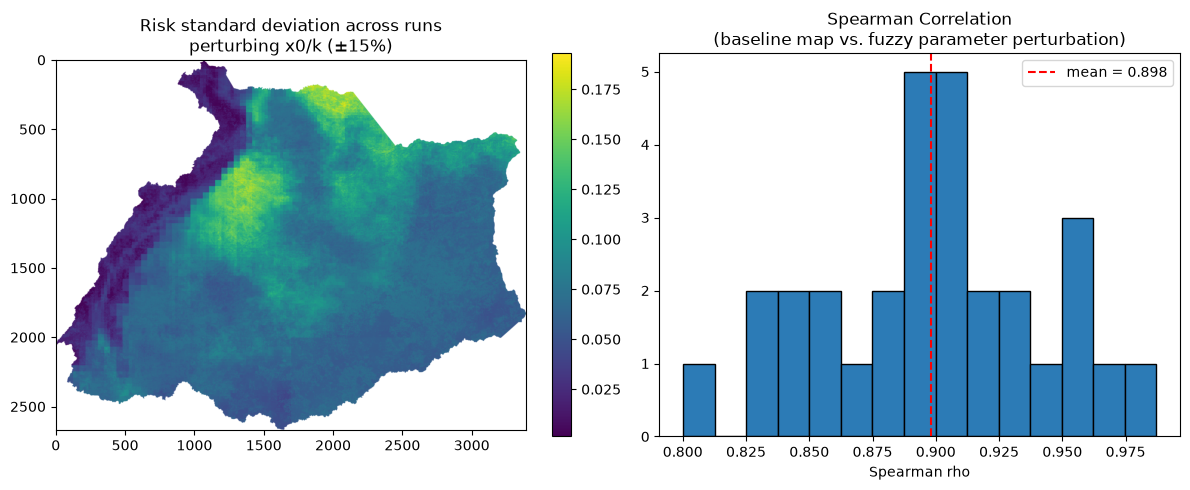

Saved to outputs/09_weight_sensitivity\fuzzy_params/


In [41]:
def fuzzy_sigmoid_numpy(arr, x0, k):
    return 1 / (1 + np.exp(-k * (arr - x0)))


def perturb_fuzzy_params(params, rng, pct=FUZZY_PERTURBATION):
    perturbed = {}
    for name, p in params.items():
        perturbed[name] = {
            'x0': p['x0'] * (1 + rng.uniform(-pct, pct)),
            'k':  p['k'] * (1 + rng.uniform(-pct, pct)),
        }
    return perturbed


def compute_fuzzy_arrays_from_params(raw_arrays, fixed_arrays, params):
    out = dict(fixed_arrays)
    out['H_precip_mean'] = fuzzy_sigmoid_numpy(raw_arrays['precip_mean'], **params['precip_mean'])
    out['H_precip_cv']   = fuzzy_sigmoid_numpy(raw_arrays['precip_cv'], **params['precip_cv'])
    out['H_temp_mean']   = fuzzy_sigmoid_numpy(raw_arrays['temp_mean'], **params['temp_mean'])
    out['E_population']  = fuzzy_sigmoid_numpy(raw_arrays['pop_density'], **params['pop_density'])
    out['V_ndvi']                = fuzzy_sigmoid_numpy(raw_arrays['ndvi_mean'], **params['ndvi_mean'])
    out['V_slope']               = fuzzy_sigmoid_numpy(raw_arrays['slope'], **params['slope'])
    out['V_soil_organic_carbon'] = fuzzy_sigmoid_numpy(raw_arrays['soil_organic_carbon'], **params['soil_organic_carbon'])
    out['V_burned_frequency'] = fuzzy_sigmoid_numpy(raw_arrays['burned_frequency'], **params['burned_frequency'])
    out['V_nightlights']   = fuzzy_sigmoid_numpy(raw_arrays['nightlights'], **params['nightlights'])
    out['V_accessibility'] = fuzzy_sigmoid_numpy(raw_arrays['accessibility'], **params['accessibility'])
    out['V_built_surface'] = fuzzy_sigmoid_numpy(raw_arrays['built_surface'], **params['built_surface'])
    return out


fixed_fuzzy_arrays = {k: fuzzy_arrays[k] for k in ['E_cropland', 'E_wetland', 'E_water', 'E_built', 'E_grass']}

fuzzy_param_runs = []
for _ in range(N_RUNS):
    perturbed_params = perturb_fuzzy_params(FUZZY_PARAMS, rng)
    run_fuzzy = compute_fuzzy_arrays_from_params(raw_indicator_arrays, fixed_fuzzy_arrays, perturbed_params)
    run_risk = compute_risk_numpy(
        run_fuzzy, weights_hazard, weights_exposure, weights_sensitivity, weights_adaptive_capacity,
        weights_vulnerability_subcomponents, weights_components, GAMMA
    )
    fuzzy_param_runs.append(run_risk)

fuzzy_param_stack = np.stack(fuzzy_param_runs, axis=0)
risk_std_fuzzy_params = fuzzy_param_stack.std(axis=0)


with rasterio.open(os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_H_precip_mean_{EVAL_YEAR}.tif')) as _src:
    study_area_mask = np.isfinite(_src.read(1))

flat_baseline = baseline_risk.flatten()
_mask_flat = study_area_mask.flatten()


fuzzy_param_correlations = []
for run in fuzzy_param_runs:
    _rf = run.flatten()
    _v = _mask_flat
    rho, _ = spearmanr(flat_baseline[_v], _rf[_v])
    fuzzy_param_correlations.append(rho)


_fp_valid = risk_std_fuzzy_params[study_area_mask]
risk_std_fuzzy_params_show = np.where(study_area_mask, risk_std_fuzzy_params, np.nan)

print(f'Sensitivity to fuzzification parameters (±{int(FUZZY_PERTURBATION*100)}%) '
      f'— STUDY AREA: mean std dev = {_fp_valid.mean():.4f}, '
      f'max = {_fp_valid.max():.4f}')
print(f'  Spearman (subbasins only): mean = {np.mean(fuzzy_param_correlations):.3f}, '
      f'min = {np.min(fuzzy_param_correlations):.3f} '
      f'({int((~study_area_mask).sum())} px outside the grid are excluded)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(risk_std_fuzzy_params_show, cmap='viridis')
axes[0].set_title(f'Risk standard deviation across runs\nperturbing x0/k (±{int(FUZZY_PERTURBATION*100)}%)')
fig.colorbar(im1, ax=axes[0], fraction=0.046)

axes[1].hist(fuzzy_param_correlations, bins=15, color='#2c7bb6', edgecolor='black')
axes[1].axvline(np.mean(fuzzy_param_correlations), color='red', linestyle='--',
                 label=f'mean = {np.mean(fuzzy_param_correlations):.3f}')
axes[1].set_title('Spearman Correlation\n(baseline map vs. fuzzy parameter perturbation)')
axes[1].set_xlabel('Spearman rho'); axes[1].legend()
plt.tight_layout()

fuzzy_param_dir = os.path.join(OUTPUT_DIRS['sensitivity'], 'fuzzy_params')
os.makedirs(fuzzy_param_dir, exist_ok=True)
fuzzy_param_fig_path = os.path.join(fuzzy_param_dir, 'fuzzy_param_sensitivity.png')
plt.savefig(fuzzy_param_fig_path, dpi=300, bbox_inches='tight')
plt.show()

with rasterio.open(os.path.join(OUTPUT_DIRS['fuzzy'], f'fuzzy_H_precip_mean_{EVAL_YEAR}.tif')) as ref:
    out_meta_fp = ref.meta.copy()
    out_meta_fp.update(dtype='float32', count=1)
fuzzy_param_std_path = os.path.join(fuzzy_param_dir, 'risk_std_fuzzy_params.tif')
with rasterio.open(fuzzy_param_std_path, 'w', **out_meta_fp) as dst:
    dst.write(risk_std_fuzzy_params_show.astype('float32'), 1)
write_geotiff_metadata(fuzzy_param_std_path, extra_tags={'ANALYSIS': 'fuzzy parameter sensitivity std'})

print(f'Saved to {fuzzy_param_dir}/')

### 14.2 Combined Uncertainty Map (Weights + Fuzzification Parameters)

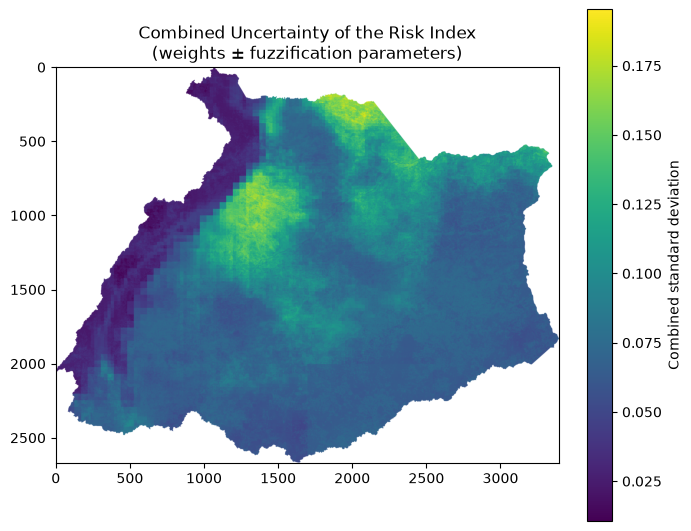

Combined uncertainty map saved to outputs/09_weight_sensitivity\combined_uncertainty_map.png and outputs/09_weight_sensitivity\combined_uncertainty.tif
Methodological note: this is combined assuming independence between both sources of uncertainty (sum of variances) — a simple approximation, not a formal uncertainty-propagation analysis.


In [42]:
std_weights_total = sensitivity_results['All']['risk_std']
combined_std = np.sqrt(std_weights_total**2 + risk_std_fuzzy_params**2)
combined_std_show = np.where(study_area_mask, combined_std, np.nan)
combined_std_show = np.where(study_area_mask, combined_std, np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(combined_std_show, cmap='viridis')
ax.set_title('Combined Uncertainty of the Risk Index\n(weights ± fuzzification parameters)')
fig.colorbar(im, ax=ax, fraction=0.046, label='Combined standard deviation')
plt.tight_layout()

combined_fig_path = os.path.join(OUTPUT_DIRS['sensitivity'], 'combined_uncertainty_map.png')
plt.savefig(combined_fig_path, dpi=300, bbox_inches='tight')
plt.show()

combined_std_path = os.path.join(OUTPUT_DIRS['sensitivity'], 'combined_uncertainty.tif')
with rasterio.open(combined_std_path, 'w', **out_meta_fp) as dst:
    dst.write(combined_std_show.astype('float32'), 1)
write_geotiff_metadata(combined_std_path, extra_tags={'ANALYSIS': 'combined uncertainty (weights + fuzzy params)'})

print(f'Combined uncertainty map saved to {combined_fig_path} and {combined_std_path}')
print('Methodological note: this is combined assuming independence between both '
      'sources of uncertainty (sum of variances) — a simple approximation, not a '
      'formal uncertainty-propagation analysis.')

## 15. Executive Summary Table for the Poster

In [43]:
gdf_area = gdf_subbasins[[SUBBASIN_ID_COL, 'geometry']].to_crs('EPSG:6933')
df_area = pd.DataFrame({
    SUBBASIN_ID_COL: gdf_subbasins[SUBBASIN_ID_COL].values,
    'area_km2': gdf_area.geometry.area.values / 1e6,
})

df_poster_summary = df_zonal.merge(df_area, on=SUBBASIN_ID_COL, how='left')
df_poster_summary = df_poster_summary.merge(
    df_components[[SUBBASIN_ID_COL, 'dominant_component', 'dominant_share_pct']], on=SUBBASIN_ID_COL, how='left'
)


if 'gdf_events' in globals() and len(historical_events) > 0:
    events_joined = gpd.sjoin(gdf_events, gdf_subbasins[[SUBBASIN_ID_COL, 'geometry']], predicate='within')
    counts = events_joined.groupby(SUBBASIN_ID_COL).size().rename('n_historical_events')
    df_poster_summary = df_poster_summary.merge(counts, on=SUBBASIN_ID_COL, how='left')
    df_poster_summary['n_historical_events'] = df_poster_summary['n_historical_events'].fillna(0).astype(int)

df_poster_summary = df_poster_summary.rename(columns={
    'risk_mean_ref': f'risk_{REF_YEAR}',
    'risk_mean_eval': f'risk_{EVAL_YEAR}',
    f'pct_class_4_{EVAL_YEAR}': f'pct_high_{EVAL_YEAR}',
    f'pct_class_5_{EVAL_YEAR}': f'pct_very_high_{EVAL_YEAR}',
})

summary_cols = SUBBASIN_KEY_COLS + ['area_km2', f'risk_{REF_YEAR}', f'risk_{EVAL_YEAR}', 'risk_change',
                f'pct_high_{EVAL_YEAR}', f'pct_very_high_{EVAL_YEAR}',
                'dominant_component', 'dominant_share_pct']
if 'n_historical_events' in df_poster_summary.columns:
    summary_cols.append('n_historical_events')

df_poster_summary = df_poster_summary[summary_cols].sort_values(f'risk_{EVAL_YEAR}', ascending=False)

summary_path = os.path.join(OUTPUT_DIRS['zonal_stats'], 'executive_summary_by_subbasin.csv')
df_poster_summary.to_csv(summary_path, index=False)
print(f'Executive summary table saved to {summary_path} — ready to cite in the poster text.')
df_poster_summary

Executive summary table saved to outputs/07_zonal_statistics\executive_summary_by_subbasin.csv — ready to cite in the poster text.


,OBJECTID_1,NOM_SZH,area_km2,risk_2024,risk_2025,risk_change,pct_high_2025,pct_very_high_2025,dominant_component,dominant_share_pct
0,107,Directos Río Arauca (md),2918.067723,0.532015,0.663589,0.131574,2.188748,95.607716,Change in Hazard,59.678908
9,111,Río Cinaruco y Directos Río Orinoco,4546.374899,0.641915,0.662906,0.020991,2.104164,97.353177,Change in Hazard,56.441174
11,117,Directos Bajo Meta entre ríos Casanare y Orinoco,6300.963236,0.637037,0.651500,0.014463,0.956525,99.043475,Change in Hazard,54.916667
1,291,Caño Samuco,915.282526,0.570641,0.637998,0.067358,3.240585,96.752678,Change in Hazard,56.879102
36,122,Río Vita,8177.186664,0.635043,0.608353,-0.026690,15.962140,83.886027,Change in Hazard,51.852123
...,...,...,...,...,...,...,...,...,...,...
30,142,Río Guatiquía,1780.533686,0.326343,0.307766,-0.018577,0.142475,NaN,Change in Vulnerability,51.567428
31,173,Río Papunaya,6831.138589,0.321941,0.303153,-0.018789,NaN,NaN,Change in Vulnerability,80.346026
21,146,Rio Metica (Guamal - Humadea),3844.201813,0.305837,0.297294,-0.008543,0.032237,NaN,Change in Vulnerability,44.971891
41,162,Alto Guaviare,10367.339063,0.326944,0.287881,-0.039063,0.348814,0.001197,Change in Vulnerability,63.649120


## 17. Final Export of Results

In [44]:
for year, comps in components_by_year.items():
    for name, img in comps.items():
        export_ee_image_robust(
            img,
            os.path.join(OUTPUT_DIRS['components'], f'{name}_{year}.tif'),
            region=aoi, scale=ANALYSIS_SCALE,
        )

export_ee_image_robust(
    risk_change,
    os.path.join(OUTPUT_DIRS['final_export'], f'climate_risk_change_{REF_YEAR}_{EVAL_YEAR}.tif'),
    region=aoi, scale=ANALYSIS_SCALE,
)

print('\nAll results exported, organized by step inside outputs/:')
for _name, _path in OUTPUT_DIRS.items():
    if _name == 'tiles_tmp':
        continue
    files = sorted(os.listdir(_path)) if os.path.isdir(_path) else []
    print(f'\n{_path}/')
    for f in files:
        print(f'  - {f}')


cleanup_tiles_tmp()

  outputs/04_components_hazard_exposure_vulnerability\Hazard_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Exposure_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Vulnerability_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Sensitivity_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\AdaptiveCapacity_Index_2024.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Hazard_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Exposure_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Vulnerability_Index_2025.tif already exists, reusing it.
  outputs/04_components_hazard_exposure_vulnerability\Sensitivity_Index_2025.tif already exists, reusing it.
  outputs/04_components_ha